# 📊 Exploratory Data Analysis (EDA)
### Metodologi CRISP-DM: Business Understanding & Data Understanding
---
> **Petunjuk Penggunaan:**
> - Ganti semua bagian bertanda `# 🔧 SESUAIKAN` dengan nilai yang sesuai dataset kamu
> - Jalankan sel secara berurutan dari atas ke bawah
> - Setiap blok dikelompokkan sesuai tahapan CRISP-DM

---
## DATA UNDERSTANDING
### Tahap 1 — Import Library

In [ ]:
# ============================================================
# 1. IMPORT LIBRARY
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, shapiro, kstest, normaltest
import warnings

# Library tambahan (aktifkan jika dibutuhkan)
# from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler
# from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
# from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

warnings.filterwarnings('ignore')

# Pengaturan tampilan
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 100

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


In [ ]:
# Upload dataset ke github
# Periksa RAW
# Copy link URL RAW pasti ke sini, pastikan beri spasi dari data/
# 🔧 SESUAIKAN: pastikan file 'data_pinjaman.csv' sudah di-upload ke repo GitHub kamu
#              (repo yang sama seperti dataset sebelumnya), lalu ambil link RAW-nya.

!wget -P data/ https://raw.githubusercontent.com/rizkimshafardataanalyst-design/PPKD-JAKSEL/refs/heads/main/data%20pinjaman.csv


--2026-08-13 08:10:07--  https://raw.githubusercontent.com/rizkimshafardataanalyst-design/PPKD-JAKSEL/refs/heads/main/data%20pinjaman.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5837648 (5.6M) [text/plain]
Saving to: ‘data/data pinjaman.csv.2’

data pinjaman.csv.2 100%[===================>]   5.57M  --.-KB/s    in 0.04s   

2026-08-13 08:10:08 (132 MB/s) - ‘data/data pinjaman.csv.2’ saved [5837648/5837648]



In [ ]:
# ============================================================
# 2. IMPORT DATASET
# ============================================================

# Membaca file sesuai format
df = pd.read_csv('data/data pinjaman.csv', sep=",")   # 🔧 SESUAIKAN: dataset pinjaman menggunakan separator ";"
# df = pd.read_excel(FILE_PATH, sheet_name='Sheet1')             # Excel  # 🔧 sesuaikan sheet_name

print("✅ Dataset berhasil diload!")
print(f"   Jumlah baris    : {df.shape[0]:,}")
print(f"   Jumlah kolom    : {df.shape[1]:,}")


✅ Dataset berhasil diload!
   Jumlah baris    : 50,000
   Jumlah kolom    : 20


In [ ]:
# ============================================================
# 3. MEMBACA DATASET — Gambaran Awal
# ============================================================

df

,id_pelanggan,usia,status_pekerjaan,lama_bekerja_tahun,pendapatan_tahunan,skor_kredit,lama_riwayat_kredit_tahun,aset_tabungan,hutang_saat_ini,gagal_bayar_tercatat,tunggakan_2thn_terakhir,catatan_negatif,tipe_produk,tujuan_pinjaman,jumlah_pinjaman,suku_bunga,rasio_hutang_terhadap_pendapatan,rasio_pinjaman_terhadap_pendapatan,rasio_pembayaran_terhadap_pendapatan,status_pinjaman
0,CUST100000,40.0000,Bekerja,17.2000,25579,692,5.3000,895,10820,0,0,0,Kartu Kredit,Bisnis,600,17.0200,0.4230,0.0230,0.0080,1
1,CUST100001,33.0000,Bekerja,7.3000,43087,627,3.5000,169,16550,0,1,0,Pinjaman Pribadi,Renovasi Rumah,53300,14.1000,0.3840,1.2370,0.4120,0
2,CUST100002,42.0000,Mahasiswa,1.1000,20840,689,8.4000,17,7852,0,0,0,Kartu Kredit,Konsolidasi Hutang,2100,18.3300,0.3770,0.1010,0.0340,1
3,CUST100003,53.0000,Mahasiswa,0.5000,29147,692,9.8000,1480,11603,0,1,0,Kartu Kredit,Bisnis,2900,18.7400,0.3980,0.0990,0.0330,1
4,CUST100004,32.0000,Bekerja,12.5000,63657,630,7.2000,209,12424,0,0,0,Pinjaman Pribadi,Pendidikan,99600,13.9200,0.1950,1.5650,0.5220,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,CUST149995,35.0000,Bekerja,4.3000,39449,570,16.3000,1127,7576,0,0,0,Kartu Kredit,Pendidikan,42800,21.3100,0.1920,1.0850,0.3620,0
49996,CUST149996,34.0000,Bekerja,4.4000,20496,672,12.6000,1478,6276,1,0,0,Kartu Kredit,Pribadi,3800,18.0700,0.3060,0.1850,0.0620,0
49997,CUST149997,41.0000,Wiraswasta,4.8000,18743,719,10.1000,17,10331,0,0,0,Kartu Kredit,Pribadi,18000,17.4500,0.5510,0.9600,0.3200,0
49998,CUST149998,38.0000,Mahasiswa,0.4000,17250,633,1.3000,5,7779,0,0,1,Pinjaman Pribadi,Pribadi,1400,14.7100,0.4510,0.0810,0.0270,0


In [ ]:
# ============================================================
# 4. df.info() — Tipe Data & Non-Null Count
# ============================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   id_pelanggan                          50000 non-null  object 
 1   usia                                  49853 non-null  float64
 2   status_pekerjaan                      49847 non-null  object 
 3   lama_bekerja_tahun                    50000 non-null  float64
 4   pendapatan_tahunan                    50000 non-null  int64  
 5   skor_kredit                           50000 non-null  int64  
 6   lama_riwayat_kredit_tahun             50000 non-null  float64
 7   aset_tabungan                         50000 non-null  int64  
 8   hutang_saat_ini                       50000 non-null  int64  
 9   gagal_bayar_tercatat                  50000 non-null  int64  
 10  tunggakan_2thn_terakhir               50000 non-null  int64  
 11  catatan_negatif

In [ ]:
# ============================================================
# 5. df.shape — Dimensi Dataset
# ============================================================

baris, kolom = df.shape
print(f"📐 Dimensi Dataset : {baris:,} baris  ×  {kolom} kolom")

📐 Dimensi Dataset : 50,000 baris  ×  20 kolom


In [ ]:
# ============================================================
# 6. META DATASET - Kamus Fitur
# ============================================================

# 🔧 SESUAIKAN: Isi penjelasan dan fungsi setiap fitur dataset kamu
meta = pd.DataFrame({
    'Nama Fitur': [
        'id_pelanggan', 'usia', 'status_pekerjaan', 'lama_bekerja_tahun',
        'pendapatan_tahunan', 'skor_kredit', 'lama_riwayat_kredit_tahun',
        'aset_tabungan', 'hutang_saat_ini', 'gagal_bayar_tercatat',
        'tunggakan_2thn_terakhir', 'catatan_negatif', 'tipe_produk',
        'tujuan_pinjaman', 'jumlah_pinjaman', 'suku_bunga',
        'rasio_hutang_terhadap_pendapatan', 'rasio_pinjaman_terhadap_pendapatan',
        'rasio_pembayaran_terhadap_pendapatan', 'status_pinjaman'
    ],
    'Penjelasan': [
        'Pengidentifikasi unik untuk setiap nasabah/pelanggan.',
        'Usia nasabah dalam tahun.',
        'Status pekerjaan nasabah (Bekerja, Wiraswasta, Mahasiswa).',
        'Durasi (lama) nasabah bekerja, dalam tahun.',
        'Total pendapatan tahunan nasabah.',
        'Skor kredit nasabah, berkisar antara 300 - 850.',
        'Durasi (lama) riwayat kredit nasabah, dalam tahun.',
        'Total nilai aset tabungan yang dimiliki nasabah.',
        'Total kewajiban hutang yang sedang berjalan.',
        'Indikator riwayat gagal bayar nasabah (0 = tidak pernah, 1 = pernah).',
        'Frekuensi tunggakan pembayaran dalam 2 tahun terakhir.',
        'Jumlah catatan riwayat finansial negatif nasabah.',
        'Kategori/jenis produk pinjaman yang diajukan.',
        'Peruntukan atau tujuan pengajuan pinjaman.',
        'Nominal jumlah pinjaman yang diajukan.',
        'Suku bunga pinjaman (%) yang dikenakan.',
        'Debt-to-Income Ratio (DTI) — rasio hutang terhadap pendapatan.',
        'Loan-to-Income Ratio — rasio jumlah pinjaman terhadap pendapatan.',
        'Payment-to-Income Ratio — rasio pembayaran terhadap pendapatan.',
        'Status kelayakan/persetujuan pinjaman (0 = ditolak, 1 = disetujui).'
    ],
    'Fungsi dalam Analisis': [
        'Info — identifier unik, bukan untuk analisis/model langsung.',
        'Fitur numerik untuk analisis profil usia nasabah.',
        'Fitur kategorikal untuk analisis segmentasi pekerjaan.',
        'Fitur numerik terkait stabilitas pekerjaan nasabah.',
        'Fitur numerik untuk analisis kapasitas finansial nasabah.',
        'Fitur numerik indikator kelayakan kredit.',
        'Fitur numerik terkait pengalaman kredit nasabah.',
        'Fitur numerik untuk analisis ketahanan finansial (aset).',
        'Fitur numerik untuk analisis beban kewajiban nasabah.',
        'Fitur numerik indikator risiko historis.',
        'Fitur numerik indikator risiko historis.',
        'Fitur numerik indikator risiko historis.',
        'Fitur kategorikal untuk analisis jenis produk pinjaman.',
        'Fitur kategorikal untuk analisis peruntukan pinjaman.',
        'Fitur numerik indikator utama besaran pengajuan.',
        'Fitur numerik terkait biaya pinjaman.',
        'Fitur numerik rasio finansial (kapasitas bayar).',
        'Fitur numerik rasio finansial (besaran pinjaman relatif).',
        'Fitur numerik rasio finansial (beban cicilan relatif).',
        'Target — variabel yang diprediksi oleh model.'
    ]
})

display(meta.style.set_properties(**{'text-align': 'left'})
             .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}]))


,Nama Fitur,Penjelasan,Fungsi dalam Analisis
0,id_pelanggan,Pengidentifikasi unik untuk setiap nasabah/pelanggan.,"Info — identifier unik, bukan untuk analisis/model langsung."
1,usia,Usia nasabah dalam tahun.,Fitur numerik untuk analisis profil usia nasabah.
2,status_pekerjaan,"Status pekerjaan nasabah (Bekerja, Wiraswasta, Mahasiswa).",Fitur kategorikal untuk analisis segmentasi pekerjaan.
3,lama_bekerja_tahun,"Durasi (lama) nasabah bekerja, dalam tahun.",Fitur numerik terkait stabilitas pekerjaan nasabah.
4,pendapatan_tahunan,Total pendapatan tahunan nasabah.,Fitur numerik untuk analisis kapasitas finansial nasabah.
5,skor_kredit,"Skor kredit nasabah, berkisar antara 300 - 850.",Fitur numerik indikator kelayakan kredit.
6,lama_riwayat_kredit_tahun,"Durasi (lama) riwayat kredit nasabah, dalam tahun.",Fitur numerik terkait pengalaman kredit nasabah.
7,aset_tabungan,Total nilai aset tabungan yang dimiliki nasabah.,Fitur numerik untuk analisis ketahanan finansial (aset).
8,hutang_saat_ini,Total kewajiban hutang yang sedang berjalan.,Fitur numerik untuk analisis beban kewajiban nasabah.
9,gagal_bayar_tercatat,"Indikator riwayat gagal bayar nasabah (0 = tidak pernah, 1 = pernah).",Fitur numerik indikator risiko historis.


In [ ]:
# ============================================================
# 7. MENAMPILKAN 5 DATA TERATAS
# ============================================================

print("5 Data Teratas:")
df.head()

5 Data Teratas:


,id_pelanggan,usia,status_pekerjaan,lama_bekerja_tahun,pendapatan_tahunan,skor_kredit,lama_riwayat_kredit_tahun,aset_tabungan,hutang_saat_ini,gagal_bayar_tercatat,tunggakan_2thn_terakhir,catatan_negatif,tipe_produk,tujuan_pinjaman,jumlah_pinjaman,suku_bunga,rasio_hutang_terhadap_pendapatan,rasio_pinjaman_terhadap_pendapatan,rasio_pembayaran_terhadap_pendapatan,status_pinjaman
0,CUST100000,40.0000,Bekerja,17.2000,25579,692,5.3000,895,10820,0,0,0,Kartu Kredit,Bisnis,600,17.0200,0.4230,0.0230,0.0080,1
1,CUST100001,33.0000,Bekerja,7.3000,43087,627,3.5000,169,16550,0,1,0,Pinjaman Pribadi,Renovasi Rumah,53300,14.1000,0.3840,1.2370,0.4120,0
2,CUST100002,42.0000,Mahasiswa,1.1000,20840,689,8.4000,17,7852,0,0,0,Kartu Kredit,Konsolidasi Hutang,2100,18.3300,0.3770,0.1010,0.0340,1
3,CUST100003,53.0000,Mahasiswa,0.5000,29147,692,9.8000,1480,11603,0,1,0,Kartu Kredit,Bisnis,2900,18.7400,0.3980,0.0990,0.0330,1
4,CUST100004,32.0000,Bekerja,12.5000,63657,630,7.2000,209,12424,0,0,0,Pinjaman Pribadi,Pendidikan,99600,13.9200,0.1950,1.5650,0.5220,1


In [ ]:
# ============================================================
# 8. MENAMPILKAN 5 DATA TERAKHIR
# ============================================================

print("5 Data Terakhir:")
df.tail()

5 Data Terakhir:


,id_pelanggan,usia,status_pekerjaan,lama_bekerja_tahun,pendapatan_tahunan,skor_kredit,lama_riwayat_kredit_tahun,aset_tabungan,hutang_saat_ini,gagal_bayar_tercatat,tunggakan_2thn_terakhir,catatan_negatif,tipe_produk,tujuan_pinjaman,jumlah_pinjaman,suku_bunga,rasio_hutang_terhadap_pendapatan,rasio_pinjaman_terhadap_pendapatan,rasio_pembayaran_terhadap_pendapatan,status_pinjaman
49995,CUST149995,35.0000,Bekerja,4.3000,39449,570,16.3000,1127,7576,0,0,0,Kartu Kredit,Pendidikan,42800,21.3100,0.1920,1.0850,0.3620,0
49996,CUST149996,34.0000,Bekerja,4.4000,20496,672,12.6000,1478,6276,1,0,0,Kartu Kredit,Pribadi,3800,18.0700,0.3060,0.1850,0.0620,0
49997,CUST149997,41.0000,Wiraswasta,4.8000,18743,719,10.1000,17,10331,0,0,0,Kartu Kredit,Pribadi,18000,17.4500,0.5510,0.9600,0.3200,0
49998,CUST149998,38.0000,Mahasiswa,0.4000,17250,633,1.3000,5,7779,0,0,1,Pinjaman Pribadi,Pribadi,1400,14.7100,0.4510,0.0810,0.0270,0
49999,CUST149999,53.0000,Bekerja,17.2000,46923,695,15.0000,8332,2655,0,1,0,Pinjaman Pribadi,Pribadi,41000,12.3900,0.0570,0.8740,0.2910,1


In [ ]:
# ============================================================
# 9. KEUNIKAN FITUR KATEGORIKAL
# ============================================================

kolom_kategorikal = ['status_pekerjaan', 'tipe_produk', 'tujuan_pinjaman']  # 🔧 SESUAIKAN: id_pelanggan dikecualikan karena identifier unik (kardinalitas tinggi)
print(f"Kolom kategorikal terdeteksi: {kolom_kategorikal}\n")

for col in kolom_kategorikal:
    unique_vals = df[col].unique()
    print(f"📌 '{col}' ({df[col].nunique()} nilai unik):")
    print(f"   {unique_vals}")
    print(f"   Value counts:")
    vc = df[col].value_counts().to_string()
    for line in vc.split('\n'):
        print(f"    {line}")
    print()


Kolom kategorikal terdeteksi: ['status_pekerjaan', 'tipe_produk', 'tujuan_pinjaman']

📌 'status_pekerjaan' (3 nilai unik):
   ['Bekerja' 'Mahasiswa' 'Wiraswasta' nan]
   Value counts:
    status_pekerjaan
    Bekerja       34853
    Wiraswasta    10154
    Mahasiswa      4840

📌 'tipe_produk' (3 nilai unik):
   ['Kartu Kredit' 'Pinjaman Pribadi' 'Kredit Berjalan']
   Value counts:
    tipe_produk
    Kartu Kredit        22455
    Pinjaman Pribadi    17523
    Kredit Berjalan     10022

📌 'tujuan_pinjaman' (6 nilai unik):
   ['Bisnis' 'Renovasi Rumah' 'Konsolidasi Hutang' 'Pendidikan' 'Pribadi'
 'Medis']
   Value counts:
    tujuan_pinjaman
    Pribadi               12429
    Pendidikan            10134
    Medis                  7598
    Bisnis                 7469
    Renovasi Rumah         7453
    Konsolidasi Hutang     4917



In [ ]:
# ============================================================
# 10. DESKRIPSI STATISTIK — Fitur Numerikal
# ============================================================
print("Statistik Deskriptif Fitur Numerikal:")
kolom_numerik = df.select_dtypes(include=np.number).columns.tolist()
# kolom_numerik = ['co2_ppm', 'pm25_ugm3', 'humidity_pct']  # 🔧 SESUAIKAN jika mau hanya beberapa kolom numerik

df[kolom_numerik].describe()

Statistik Deskriptif Fitur Numerikal:


,usia,lama_bekerja_tahun,pendapatan_tahunan,skor_kredit,lama_riwayat_kredit_tahun,aset_tabungan,hutang_saat_ini,gagal_bayar_tercatat,tunggakan_2thn_terakhir,catatan_negatif,jumlah_pinjaman,suku_bunga,rasio_hutang_terhadap_pendapatan,rasio_pinjaman_terhadap_pendapatan,rasio_pembayaran_terhadap_pendapatan,status_pinjaman
count,49853.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000
mean,34.9570,7.4549,50062.8920,643.6148,8.1683,3595.6194,14290.4422,0.0535,0.5546,0.1476,33041.8740,15.4986,0.2857,0.7020,0.2340,0.5505
std,11.1152,7.6121,32630.5010,64.7315,7.2076,13232.3994,13243.7575,0.2250,0.8450,0.4130,26116.1851,4.0679,0.1598,0.4658,0.1553,0.4975
min,18.0000,0.0000,15000.0000,348.0000,0.0000,0.0000,60.0000,0.0000,0.0000,0.0000,500.0000,6.0000,0.0020,0.0080,0.0030,0.0000
25%,26.0000,1.3000,27280.5000,600.0000,2.0000,130.0000,5581.0000,0.0000,0.0000,0.0000,12300.0000,12.1800,0.1610,0.3330,0.1110,0.0000
50%,35.0000,4.9000,41607.5000,643.0000,6.1000,568.0000,10385.0000,0.0000,0.0000,0.0000,26100.0000,15.4400,0.2650,0.6220,0.2070,1.0000
75%,43.0000,11.4000,62723.2500,687.0000,12.6000,2271.0000,18449.2500,0.0000,1.0000,0.0000,48500.0000,18.8700,0.3890,1.0103,0.3370,1.0000
max,70.0000,39.9000,250000.0000,850.0000,30.0000,300000.0000,163344.0000,1.0000,9.0000,4.0000,100000.0000,23.0000,0.8000,2.0010,0.6670,1.0000


# CEK SKEWNESS (Kemiringan Distribusi)

In [ ]:
# ============================================================
# 11. CEK SKEWNESS (Kemiringan Distribusi)
# ============================================================

print("Interpretasi:")
print("  Skewness ≈ 0        : Distribusi simetris (normal)")
print("  Skewness > +0.5     : Miring kanan (positif skew)")
print("  Skewness < -0.5     : Miring kiri (negatif skew)")
print("  |Skewness| > 1      : Sangat miring")
print()

skewness_df = df[kolom_numerik].skew().reset_index()
skewness_df.columns = ['Fitur', 'Skewness']
skewness_df['Interpretasi'] = skewness_df['Skewness'].apply(
    lambda x: '⚠️ Sangat miring kanan' if x > 1
    else ('⚠️ Sangat miring kiri' if x < -1
    else ('↗️ Miring kanan' if x > 0.5
    else ('↙️ Miring kiri' if x < -0.5
    else '✅ Simetris')))
)
display(skewness_df)

Interpretasi:
  Skewness ≈ 0        : Distribusi simetris (normal)
  Skewness > +0.5     : Miring kanan (positif skew)
  Skewness < -0.5     : Miring kiri (negatif skew)
  |Skewness| > 1      : Sangat miring



,Fitur,Skewness,Interpretasi
0,usia,0.3350,✅ Simetris
1,lama_bekerja_tahun,1.2936,⚠️ Sangat miring kanan
2,pendapatan_tahunan,1.8879,⚠️ Sangat miring kanan
3,skor_kredit,0.0130,✅ Simetris
4,lama_riwayat_kredit_tahun,0.9538,↗️ Miring kanan
5,aset_tabungan,12.0549,⚠️ Sangat miring kanan
6,hutang_saat_ini,2.4378,⚠️ Sangat miring kanan
7,gagal_bayar_tercatat,3.9694,⚠️ Sangat miring kanan
8,tunggakan_2thn_terakhir,1.8169,⚠️ Sangat miring kanan
9,catatan_negatif,3.1175,⚠️ Sangat miring kanan


# CEK KURTOSIS

In [ ]:
# ============================================================
# 12. CEK KURTOSIS
# ============================================================

print("Interpretasi (Excess Kurtosis):")
print("  Kurtosis ≈ 0  : Mesokurtik (normal)")
print("  Kurtosis > 0  : Leptokurtik (ekor berat/lancip)")
print("  Kurtosis < 0  : Platikurtik (ekor tipis/datar)")
print()

kurtosis_df = df[kolom_numerik].kurtosis().reset_index()
kurtosis_df.columns = ['Fitur', 'Kurtosis']
kurtosis_df['Interpretasi'] = kurtosis_df['Kurtosis'].apply(
    lambda x: '🔺 Leptokurtik (ekor berat)' if x > 1
    else ('🔻 Platikurtik (ekor tipis)' if x < -1
    else '✅ Mesokurtik (normal)')
)
display(kurtosis_df)
# Kode ini berfungsi untuk menghitung dan menginterpretasi kurtosis (keruncingan distribusi) dari fitur-fitur numerik dalam dataset Anda. Kurtosis adalah ukuran seberapa "tajam" puncak distribusi atau seberapa "berat" ekor distribusi dibandingkan dengan distribusi normal.

# Berikut rincian cara kerjanya:

# 1.  Mengambil Kolom Numerik: Kode pertama-tama mengambil semua kolom numerik dari DataFrame df (yang telah didefinisikan sebelumnya sebagai kolom_numerik).
# 2.  Menghitung Kurtosis: Menggunakan metode .kurtosis() dari pandas, kode menghitung nilai kurtosis untuk setiap kolom numerik.
# 3.  Membuat DataFrame Hasil: Hasil perhitungan kurtosis disusun ke dalam sebuah DataFrame bernama kurtosis_df dengan dua kolom: 'Fitur' (nama kolom numerik) dan 'Kurtosis' (nilai kurtosis yang dihitung).
# 4.  Menginterpretasi Hasil: Kolom 'Interpretasi' ditambahkan ke kurtosis_df berdasarkan nilai kurtosis:
#     *   Leptokurtik (ekor berat): Jika nilai kurtosis (excess kurtosis) lebih besar dari 1. Ini berarti distribusi memiliki puncak yang lebih tajam dan ekor yang lebih berat (lebih banyak outlier) dibandingkan distribusi normal.
#     *   Platikurtik (ekor tipis): Jika nilai kurtosis (excess kurtosis) lebih kecil dari -1. Ini berarti distribusi memiliki puncak yang lebih datar dan ekor yang lebih tipis (lebih sedikit outlier) dibandingkan distribusi normal.
#     *   Mesokurtik (normal): Jika nilai kurtosis berada di antara -1 dan 1 (mendekati 0). Ini menunjukkan distribusi yang mirip dengan distribusi normal.
# 5.  Menampilkan Hasil: Akhirnya, display(kurtosis_df) menampilkan tabel yang berisi nama fitur, nilai kurtosis, dan interpretasinya, sehingga Anda dapat dengan mudah memahami karakteristik keruncingan setiap distribusi data numerik Anda.

Interpretasi (Excess Kurtosis):
  Kurtosis ≈ 0  : Mesokurtik (normal)
  Kurtosis > 0  : Leptokurtik (ekor berat/lancip)
  Kurtosis < 0  : Platikurtik (ekor tipis/datar)



,Fitur,Kurtosis,Interpretasi
0,usia,-0.4377,✅ Mesokurtik (normal)
1,lama_bekerja_tahun,1.2623,🔺 Leptokurtik (ekor berat)
2,pendapatan_tahunan,5.2279,🔺 Leptokurtik (ekor berat)
3,skor_kredit,-0.0438,✅ Mesokurtik (normal)
4,lama_riwayat_kredit_tahun,0.0751,✅ Mesokurtik (normal)
5,aset_tabungan,203.3895,🔺 Leptokurtik (ekor berat)
6,hutang_saat_ini,9.2589,🔺 Leptokurtik (ekor berat)
7,gagal_bayar_tercatat,13.7566,🔺 Leptokurtik (ekor berat)
8,tunggakan_2thn_terakhir,4.0914,🔺 Leptokurtik (ekor berat)
9,catatan_negatif,11.1597,🔺 Leptokurtik (ekor berat)


# CEK DISTRIBUSI — Univariat, Bivariat, Multivariat

📊 Distribusi Univariat — Histogram + KDE


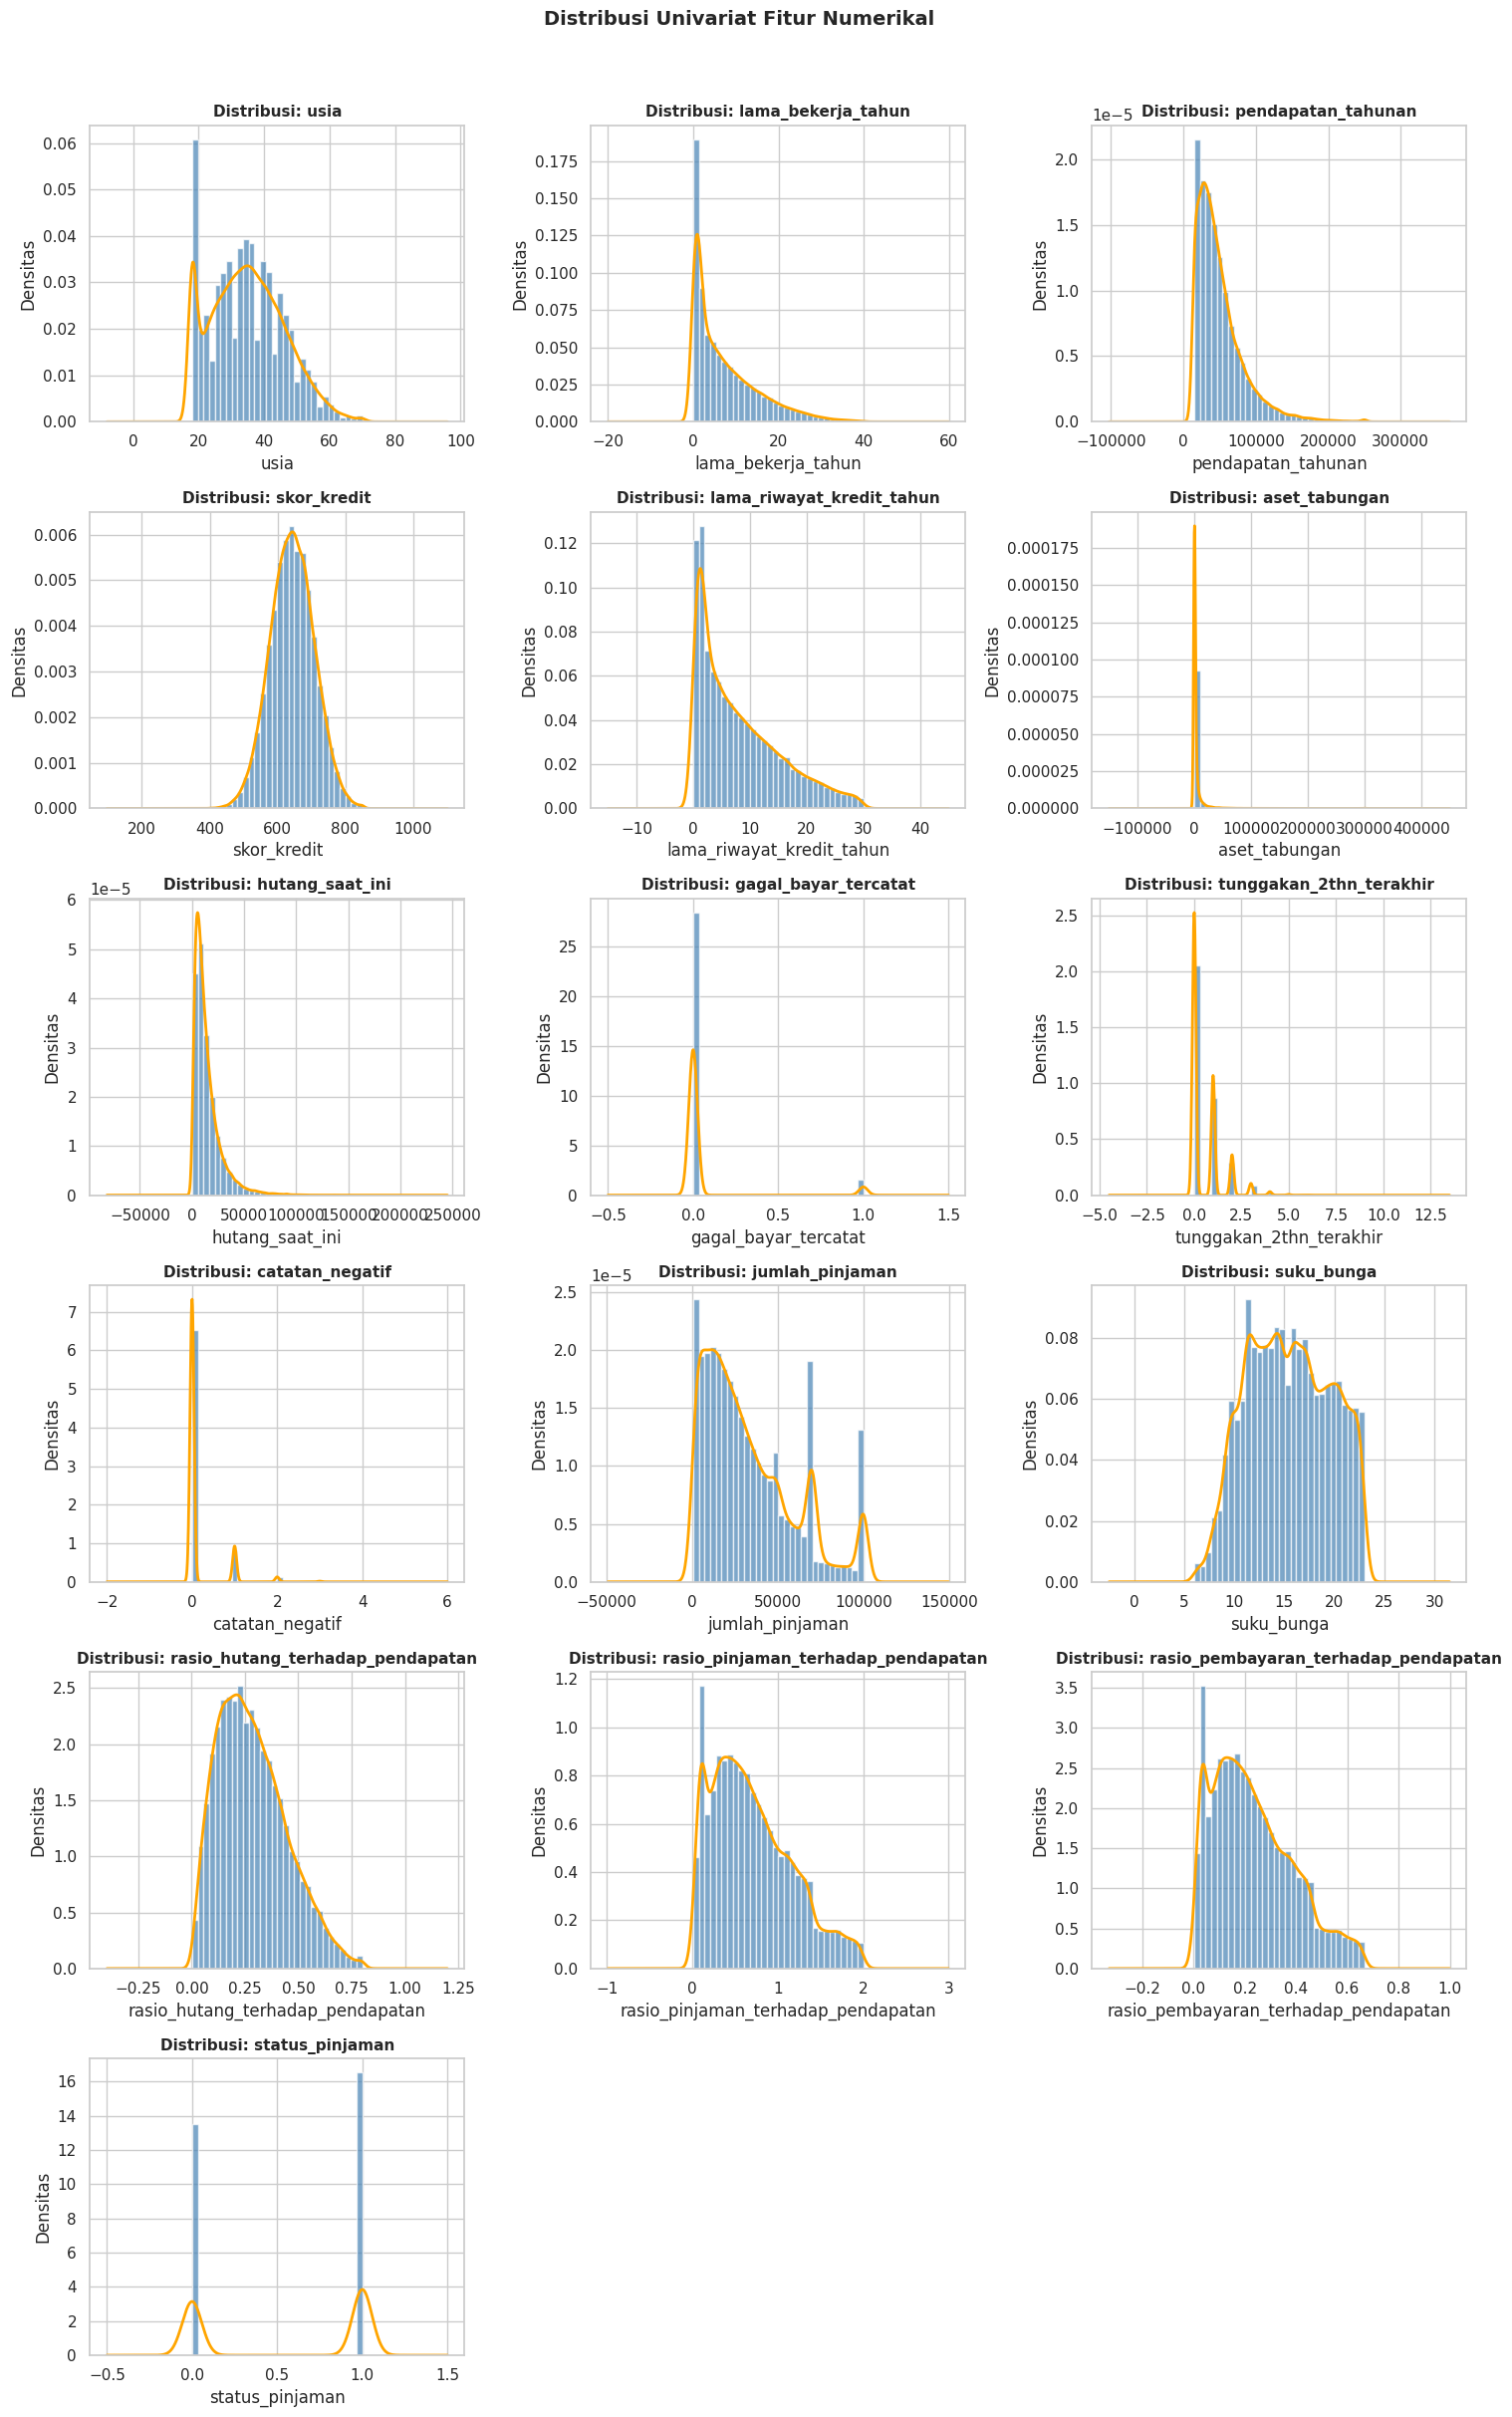

In [ ]:
# ============================================================
# 13. CEK DISTRIBUSI — Univariat, Bivariat, Multivariat
# ============================================================

# --- UNIVARIAT: Histogram + KDE setiap fitur numerik ---
print("📊 Distribusi Univariat — Histogram + KDE")
# 🔧 SESUAIKAN: ubah kolom_numerik jika ingin subset tertentu
cols_plot = [c for c in kolom_numerik if c != 'id']  # exclude ID
n_cols = 3
n_rows = (len(cols_plot) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols_plot):
    data_clean = df[col].dropna()
    axes[i].hist(data_clean, bins=30, color='steelblue', edgecolor='white', alpha=0.7, density=True)
    data_clean.plot(kind='kde', ax=axes[i], color='orange', lw=2)
    axes[i].set_title(f'Distribusi: {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Densitas')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Univariat Fitur Numerikal', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# CEK DISTRIBUSI — Uji Normalitas Statistik

In [ ]:
# ============================================================
# 13B. CEK DISTRIBUSI — Uji Normalitas Statistik
# ============================================================

print("H0: Data berdistribusi normal")
print("p-value > 0.05  → Gagal tolak H0 (distribusi NORMAL)")
print("p-value ≤ 0.05  → Tolak H0 (distribusi TIDAK NORMAL)")

# 🔧 SESUAIKAN: pilih kolom yang ingin diuji normalitasnya (target dikecualikan)
cols_uji = [c for c in kolom_numerik if c not in ['status_pinjaman']]

hasil_normalitas = []
for col in cols_uji:
    data_clean = df[col].dropna()
    # Shapiro-Wilk (terbaik untuk n < 5000)
    if len(data_clean) <= 5000:
        stat_sw, p_sw = shapiro(data_clean[:5000])
    else:
        stat_sw, p_sw = shapiro(data_clean.sample(5000, random_state=42))
    # Kolmogorov-Smirnov
    stat_ks, p_ks = kstest(data_clean, 'norm',
                           args=(data_clean.mean(), data_clean.std()))
    # D'Agostino
    stat_da, p_da = normaltest(data_clean)

    hasil_normalitas.append({
        'Fitur'           : col,
        'Shapiro-Wilk p'  : round(p_sw, 4),
        'KS p'            : round(p_ks, 4),
        "D'Agostino p"    : round(p_da, 4),
        'Normal?'         : '✅ Ya' if (p_sw > 0.05 and p_ks > 0.05) else '❌ Tidak'
    })

display(pd.DataFrame(hasil_normalitas))


H0: Data berdistribusi normal
p-value > 0.05  → Gagal tolak H0 (distribusi NORMAL)
p-value ≤ 0.05  → Tolak H0 (distribusi TIDAK NORMAL)


,Fitur,Shapiro-Wilk p,KS p,D'Agostino p,Normal?
0,usia,0.0000,0.0000,0.0000,❌ Tidak
1,lama_bekerja_tahun,0.0000,0.0000,0.0000,❌ Tidak
2,pendapatan_tahunan,0.0000,0.0000,0.0000,❌ Tidak
3,skor_kredit,0.1616,0.0273,0.0625,❌ Tidak
4,lama_riwayat_kredit_tahun,0.0000,0.0000,0.0000,❌ Tidak
5,aset_tabungan,0.0000,0.0000,0.0000,❌ Tidak
6,hutang_saat_ini,0.0000,0.0000,0.0000,❌ Tidak
7,gagal_bayar_tercatat,0.0000,0.0000,0.0000,❌ Tidak
8,tunggakan_2thn_terakhir,0.0000,0.0000,0.0000,❌ Tidak
9,catatan_negatif,0.0000,0.0000,0.0000,❌ Tidak


# CEK DISTRIBUSI MIRING (Skewed Distribution)

📊 Visualisasi Distribusi Miring vs Normal


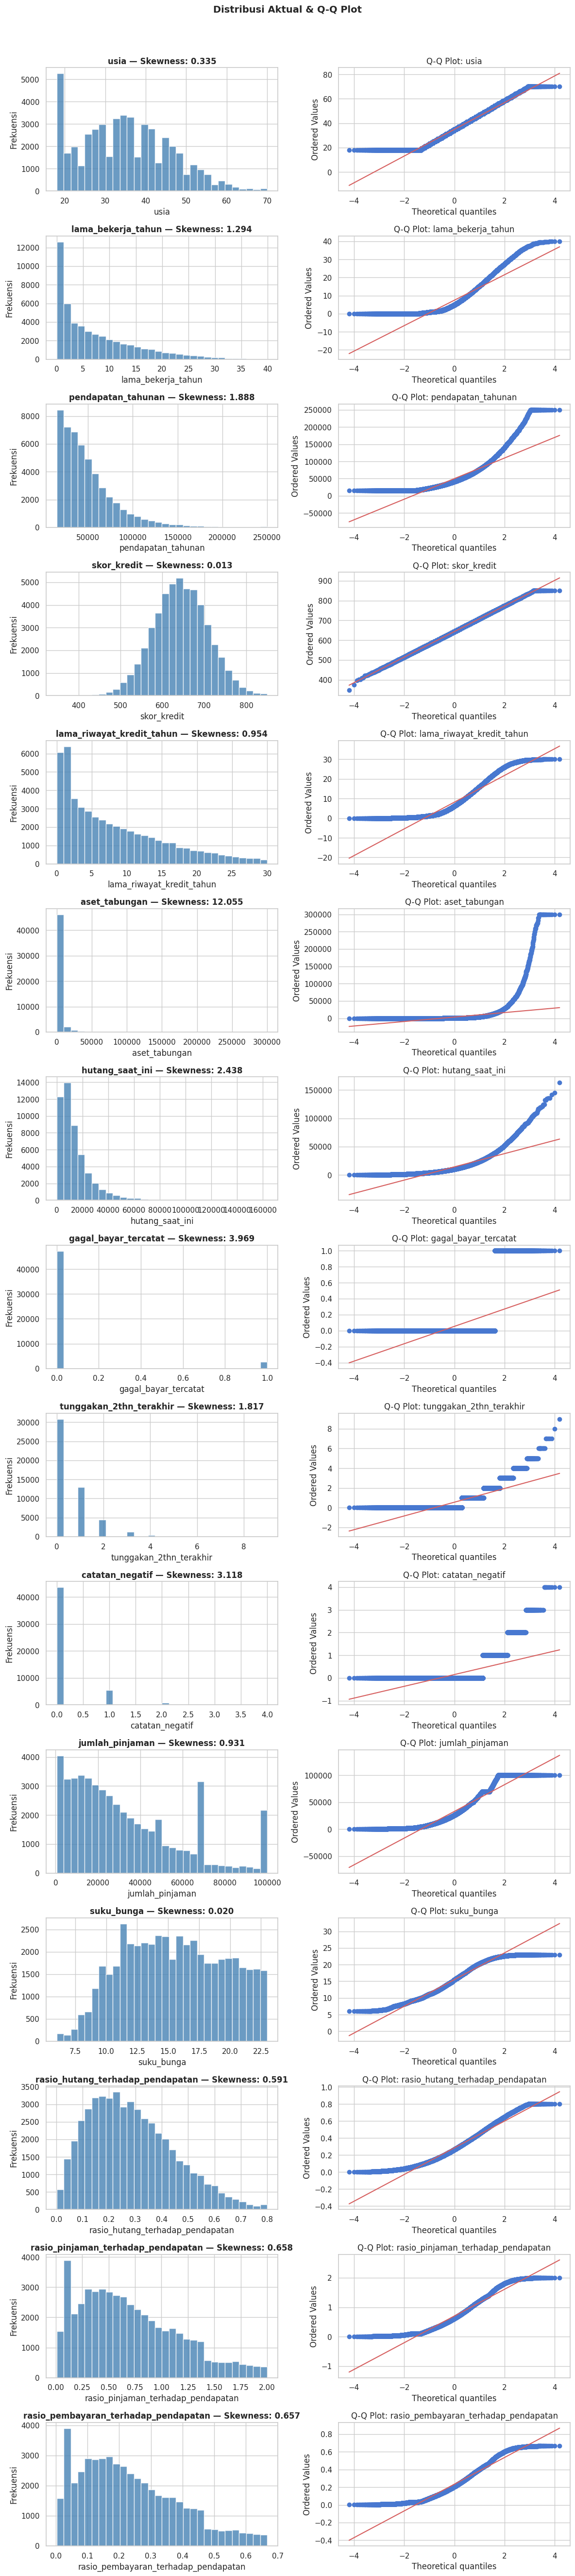

In [ ]:
# ============================================================
# 14. CEK DISTRIBUSI MIRING (Skewed Distribution)
# ============================================================
print("📊 Visualisasi Distribusi Miring vs Normal")
# 🔧 SESUAIKAN: kolom yang ingin dilihat distribusinya (target dikecualikan)
cols_skew_check = [c for c in kolom_numerik if c not in ['status_pinjaman']]

fig, axes = plt.subplots(len(cols_skew_check), 2,
                          figsize=(12, len(cols_skew_check) * 3.5))
if len(cols_skew_check) == 1:
    axes = [axes]

for i, col in enumerate(cols_skew_check):
    data_clean = df[col].dropna()
    sk = data_clean.skew()
    # Histogram aktual
    axes[i][0].hist(data_clean, bins=30, color='steelblue',
                    edgecolor='white', alpha=0.8)
    axes[i][0].set_title(f'{col} — Skewness: {sk:.3f}', fontweight='bold')
    axes[i][0].set_xlabel(col)
    axes[i][0].set_ylabel('Frekuensi')
    # Q-Q Plot
    stats.probplot(data_clean, dist="norm", plot=axes[i][1])
    axes[i][1].set_title(f'Q-Q Plot: {col}')

plt.suptitle('Distribusi Aktual & Q-Q Plot', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


# Cleaning


## Missing Value

,Jumlah Kosong
status_pekerjaan,153
usia,147
id_pelanggan,0
lama_bekerja_tahun,0
pendapatan_tahunan,0
skor_kredit,0
lama_riwayat_kredit_tahun,0
aset_tabungan,0
hutang_saat_ini,0
gagal_bayar_tercatat,0


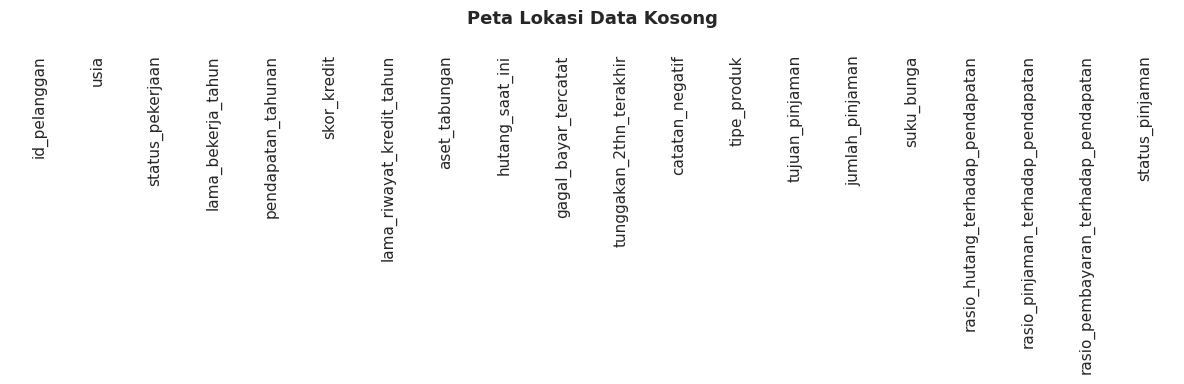

In [ ]:
# ============================================================
# 15. CEK DATA KOSONG — Ringkasan
# ============================================================

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Jumlah Kosong': missing,
}).sort_values('Jumlah Kosong', ascending=False)

display(missing_df)

# Heatmap missing values
if df.isnull().sum().sum() > 0:
    plt.figure(figsize=(12, 4))
    sns.heatmap(df.isnull(), cbar=False, cmap='Reds',
                yticklabels=False, linewidths=0.5)
    plt.title('Peta Lokasi Data Kosong', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("✅ Tidak ada data kosong!")

In [ ]:
# ============================================================
# 16. LOKASI DATA KOSONG — Index Baris
# ============================================================

kolom_kosong = df.columns[df.isnull().any()].tolist()
if kolom_kosong:
    for col in kolom_kosong:
        idx_kosong = df[df[col].isnull()].index.tolist()
        print(f"📌 Kolom '{col}' — {len(idx_kosong)} data kosong")
        print(f"   Index baris: {idx_kosong}")
        display(df.loc[idx_kosong, :].head(10))  # tampilkan maks 10 baris
else:
    print("✅ Tidak ada data kosong di seluruh kolom.")

📌 Kolom 'usia' — 147 data kosong
   Index baris: [641, 656, 872, 921, 993, 1850, 1919, 2027, 2220, 2308, 3174, 3652, 3790, 3922, 4621, 4976, 5384, 5774, 5794, 5926, 7238, 7514, 7552, 7872, 8040, 8217, 8362, 8453, 9165, 9456, 9488, 9570, 10153, 11252, 11574, 11811, 12163, 12340, 12360, 12456, 12492, 12716, 13741, 14497, 14967, 15487, 15612, 15697, 16179, 16539, 16743, 17664, 17744, 17824, 18093, 18298, 18468, 18859, 20035, 20088, 20784, 20915, 21781, 22292, 22715, 23289, 23385, 23618, 23682, 23747, 24541, 24675, 24987, 25208, 25479, 25937, 26115, 26806, 27238, 27891, 28010, 28186, 28261, 28553, 29151, 29553, 29704, 29828, 30279, 31566, 31795, 32374, 32378, 32390, 33888, 34178, 34927, 34951, 35833, 35859, 36176, 36935, 36966, 37290, 37414, 38553, 38595, 38616, 39264, 39328, 39480, 39627, 39769, 39836, 40494, 40549, 40926, 41680, 41869, 42447, 42859, 43215, 43351, 43804, 44001, 44098, 44181, 44364, 44640, 44896, 45597, 45818, 45907, 46462, 46570, 46625, 46903, 46973, 47183, 47204, 47427, 

,id_pelanggan,usia,status_pekerjaan,lama_bekerja_tahun,pendapatan_tahunan,skor_kredit,lama_riwayat_kredit_tahun,aset_tabungan,hutang_saat_ini,gagal_bayar_tercatat,tunggakan_2thn_terakhir,catatan_negatif,tipe_produk,tujuan_pinjaman,jumlah_pinjaman,suku_bunga,rasio_hutang_terhadap_pendapatan,rasio_pinjaman_terhadap_pendapatan,rasio_pembayaran_terhadap_pendapatan,status_pinjaman
641,CUST100641,NaN,Wiraswasta,14.2000,27123,730,13.9000,163,4238,0,0,0,Kredit Berjalan,Renovasi Rumah,5000,7.9700,0.1560,0.1840,0.0610,1
656,CUST100656,NaN,Bekerja,15.6000,56747,554,2.7000,173,7018,0,0,1,Kartu Kredit,Renovasi Rumah,53900,22.1400,0.1240,0.9500,0.3170,0
872,CUST100872,NaN,Wiraswasta,1.0000,64641,670,1.7000,1574,9168,0,0,0,Kartu Kredit,Pendidikan,19400,18.2100,0.1420,0.3000,0.1000,1
921,CUST100921,NaN,Bekerja,1.8000,26768,616,2.9000,126,6008,0,0,0,Kartu Kredit,Bisnis,34100,19.3400,0.2240,1.2740,0.4250,0
993,CUST100993,NaN,Bekerja,3.5000,17230,606,5.4000,50,7379,0,1,0,Kredit Berjalan,Medis,14500,12.5600,0.4280,0.8420,0.2810,0
1850,CUST101850,NaN,Bekerja,8.6000,209411,543,4.3000,6729,91567,0,1,1,Kartu Kredit,Konsolidasi Hutang,70000,22.1100,0.4370,0.3340,0.1110,0
1919,CUST101919,NaN,Bekerja,4.9000,23202,534,0.7000,53,7368,1,1,0,Pinjaman Pribadi,Bisnis,10800,15.6000,0.3180,0.4650,0.1550,0
2027,CUST102027,NaN,Bekerja,15.2000,72995,735,10.3000,861,15817,0,1,0,Kartu Kredit,Pendidikan,32800,15.8200,0.2170,0.4490,0.1500,1
2220,CUST102220,NaN,Mahasiswa,1.5000,21163,694,11.0000,3253,6685,0,0,0,Kartu Kredit,Pribadi,2100,18.8500,0.3160,0.0990,0.0330,1
2308,CUST102308,NaN,Bekerja,19.6000,28893,695,10.8000,480,7797,0,1,0,Kredit Berjalan,Medis,5100,9.2000,0.2700,0.1770,0.0590,1


📌 Kolom 'status_pekerjaan' — 153 data kosong
   Index baris: [793, 841, 902, 919, 929, 1401, 1416, 1856, 2033, 2242, 3852, 3952, 4597, 4668, 4686, 5055, 5677, 5988, 6139, 6192, 7021, 7325, 7516, 7681, 8033, 8377, 8557, 8713, 9121, 9192, 9459, 9901, 10232, 10787, 10923, 11196, 11423, 11716, 12098, 12197, 12564, 12908, 13190, 13462, 13600, 13768, 13951, 14146, 14476, 14983, 15098, 15602, 15967, 16262, 16512, 16740, 17059, 17439, 17517, 17992, 18215, 18545, 18629, 19316, 19500, 19623, 19705, 20379, 21466, 21556, 21762, 21814, 21975, 22216, 22249, 22555, 22639, 22678, 23730, 23850, 24068, 24398, 25138, 25285, 25440, 25724, 26255, 27316, 27326, 27580, 27684, 27936, 27968, 28009, 28044, 28717, 29094, 29140, 29801, 29812, 30025, 30124, 30368, 30498, 31147, 31548, 31977, 32001, 32270, 32593, 33102, 33465, 33779, 33978, 34559, 34859, 35091, 35647, 36009, 37135, 37158, 37330, 37819, 37863, 38144, 38338, 38598, 38662, 38694, 40016, 40525, 41329, 41702, 42250, 42433, 42517, 42737, 42776, 44015, 44

,id_pelanggan,usia,status_pekerjaan,lama_bekerja_tahun,pendapatan_tahunan,skor_kredit,lama_riwayat_kredit_tahun,aset_tabungan,hutang_saat_ini,gagal_bayar_tercatat,tunggakan_2thn_terakhir,catatan_negatif,tipe_produk,tujuan_pinjaman,jumlah_pinjaman,suku_bunga,rasio_hutang_terhadap_pendapatan,rasio_pinjaman_terhadap_pendapatan,rasio_pembayaran_terhadap_pendapatan,status_pinjaman
793,CUST100793,19.0000,NaN,0.1000,15909,634,2.0000,56,4042,0,3,0,Pinjaman Pribadi,Bisnis,27000,14.4100,0.2540,1.6970,0.5660,0
841,CUST100841,43.0000,NaN,4.5000,26024,634,5.5000,230,1457,0,3,0,Pinjaman Pribadi,Pribadi,13800,14.5900,0.0560,0.5300,0.1770,0
902,CUST100902,35.0000,NaN,7.6000,38021,670,8.8000,84,3144,0,0,0,Pinjaman Pribadi,Bisnis,55900,12.7600,0.0830,1.4700,0.4900,1
919,CUST100919,37.0000,NaN,5.8000,57911,688,5.3000,567,16009,0,0,0,Pinjaman Pribadi,Pendidikan,28900,12.8600,0.2760,0.4990,0.1660,1
929,CUST100929,34.0000,NaN,2.1000,42284,596,12.0000,312,2031,0,0,0,Kartu Kredit,Medis,40600,21.3000,0.0480,0.9600,0.3200,0
1401,CUST101401,41.0000,NaN,10.1000,98565,753,10.9000,624,9154,0,0,0,Kartu Kredit,Medis,70000,14.7500,0.0930,0.7100,0.2370,1
1416,CUST101416,35.0000,NaN,6.8000,37478,711,3.9000,76,15636,0,0,0,Kredit Berjalan,Bisnis,15900,9.2000,0.4170,0.4240,0.1410,0
1856,CUST101856,51.0000,NaN,14.5000,46898,615,15.8000,293,13827,0,0,0,Pinjaman Pribadi,Pendidikan,52000,13.1600,0.2950,1.1090,0.3700,1
2033,CUST102033,41.0000,NaN,13.4000,52611,534,18.8000,31469,17357,0,0,0,Kredit Berjalan,Medis,39700,13.7100,0.3300,0.7550,0.2520,1
2242,CUST102242,58.0000,NaN,26.1000,25886,782,27.6000,6061,5199,0,1,0,Kartu Kredit,Pribadi,1500,14.8400,0.2010,0.0580,0.0190,1


## Data Duplikat

In [ ]:
# ============================================================
# 17. CEK DATA DUPLIKAT — Ringkasan
# ============================================================

jml_duplikat = df.duplicated().sum()
pct_duplikat = jml_duplikat / len(df) * 100
print(f"Jumlah baris duplikat : {jml_duplikat:,}")
print(f"Persentase            : {pct_duplikat:.2f}%")
print(f"Status                : {'⚠️ Ada duplikat!' if jml_duplikat > 0 else '✅ Tidak ada duplikat'}")

Jumlah baris duplikat : 0
Persentase            : 0.00%
Status                : ✅ Tidak ada duplikat


In [ ]:
# ============================================================
# 18. LOKASI DATA DUPLIKAT — Index Baris
# ============================================================

duplikat_mask = df.duplicated(keep='first')
idx_duplikat = df[duplikat_mask].index.tolist()

if idx_duplikat:
    print(f"Index baris duplikat (yang ke-2 dst): {idx_duplikat}")
    print("\\nBaris duplikat tersebut:")
    display(df.loc[idx_duplikat])
else:
    print("✅ Tidak ada data duplikat.")

✅ Tidak ada data duplikat.


In [ ]:
# ============================================================
# 19. PENYESUAIAN TIPE DATA
# ============================================================
print("Tipe data sebelum penyesuaian:")
print(df.dtypes)
print()

# Normalize column names by stripping whitespace
df.columns = df.columns.str.strip()
print("✅ Nama kolom dinormalisasi (whitespace dihilangkan).")

# --- Float ke Integer ---
# 🔧 SESUAIKAN: daftar kolom float yang seharusnya integer (tidak ada desimal)
# Dataset ini tidak memerlukan konversi float→int (usia tetap Float64 sesuai jobsheet)
# kolom_float_ke_int = []  # 🔧 SESUAIKAN
# for col in kolom_float_ke_int:
#     if col in df.columns:
#         df[col] = df[col].fillna(0).astype(int)
#         print(f"✅ '{col}': float → int")

# --- Object ke Numeric ---
# 🔧 SESUAIKAN: kolom string berisi angka
kolom_str_ke_num = []  # 🔧 SESUAIKAN: dataset pinjaman sudah bertipe numerik bersih, tidak ada kolom string berformat angka
for col in kolom_str_ke_num:
    if col in df.columns:
        # Remove '$' and replace ',' with '.' then strip whitespace
        df[col] = df[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '.', regex=False).str.strip()
        df[col] = pd.to_numeric(df[col], errors='coerce')  # 'coerce' → NaN jika gagal
        print(f"✅ '{col}': object → numeric")

# --- Object/String ke Datetime ---
# 🔧 SESUAIKAN: kolom tanggal
kolom_datetime = []  # 🔧 SESUAIKAN: dataset pinjaman tidak memiliki kolom tanggal
for col in kolom_datetime:
    if col in df.columns and df[col].dtype == object:
        df[col] = pd.to_datetime(df[col], errors='coerce',
                                  infer_datetime_format=True)
        print(f"✅ '{col}': object → datetime")

# --- Integer ke Float (jika ada nilai desimal) ---
# kolom_int_ke_float = ['nilai_x']  # 🔧 SESUAIKAN
# df['nilai_x'] = df['nilai_x'].astype(float)

# --- Object/String ke Time ---
kolom_time = []  # 🔧 SESUAIKAN: dataset pinjaman tidak memiliki kolom waktu

for col in kolom_time:
    if col in df.columns and df[col].dtype == object:
        df[col] = pd.to_datetime(df[col], format='%H:%M:%S', errors='coerce').dt.time
        print(f"✅ '{col}': object → time")
        print(f"{df[col].dropna().head(3).tolist()}")

print("Tipe data setelah penyesuaian:")
print(df.dtypes)


Tipe data sebelum penyesuaian:
id_pelanggan                             object
usia                                    float64
status_pekerjaan                         object
lama_bekerja_tahun                      float64
pendapatan_tahunan                        int64
skor_kredit                               int64
lama_riwayat_kredit_tahun               float64
aset_tabungan                             int64
hutang_saat_ini                           int64
gagal_bayar_tercatat                      int64
tunggakan_2thn_terakhir                   int64
catatan_negatif                           int64
tipe_produk                              object
tujuan_pinjaman                          object
jumlah_pinjaman                           int64
suku_bunga                              float64
rasio_hutang_terhadap_pendapatan        float64
rasio_pinjaman_terhadap_pendapatan      float64
rasio_pembayaran_terhadap_pendapatan    float64
status_pinjaman                           int64
dtype: ob

In [ ]:
# ============================================================
# 20. PERIKSA TIPE DATA SPESIFIK — .dtypes
# ============================================================

# Cek satu kolom
print("Tipe data per kolom individual:")
print(f"  'pendapatan_tahunan' : {df['pendapatan_tahunan'].dtype}")  # 🔧 SESUAIKAN
print(f"  'status_pekerjaan'   : {df['status_pekerjaan'].dtype}")    # 🔧 SESUAIKAN
print(f"  'tipe_produk'        : {df['tipe_produk'].dtype}")         # 🔧 SESUAIKAN

# Cek beberapa kolom sekaligus
kolom_cek = ['status_pekerjaan', 'tipe_produk', 'tujuan_pinjaman']  # 🔧 SESUAIKAN
print("Tipe data beberapa kolom sekaligus:")
print(df[kolom_cek].dtypes)

# Kelompokkan per tipe
print("Ringkasan per tipe data:")
for dtype, cols in df.dtypes.groupby(df.dtypes):
    print(f"  {str(dtype):15s}: {list(cols.index)}")


Tipe data per kolom individual:
  'pendapatan_tahunan' : int64
  'status_pekerjaan'   : object
  'tipe_produk'        : object
Tipe data beberapa kolom sekaligus:
status_pekerjaan    object
tipe_produk         object
tujuan_pinjaman     object
dtype: object
Ringkasan per tipe data:
  int64          : ['pendapatan_tahunan', 'skor_kredit', 'aset_tabungan', 'hutang_saat_ini', 'gagal_bayar_tercatat', 'tunggakan_2thn_terakhir', 'catatan_negatif', 'jumlah_pinjaman', 'status_pinjaman']
  float64        : ['usia', 'lama_bekerja_tahun', 'lama_riwayat_kredit_tahun', 'suku_bunga', 'rasio_hutang_terhadap_pendapatan', 'rasio_pinjaman_terhadap_pendapatan', 'rasio_pembayaran_terhadap_pendapatan']
  object         : ['id_pelanggan', 'status_pekerjaan', 'tipe_produk', 'tujuan_pinjaman']


In [ ]:
# ============================================================
# 21. KONSISTENSI FORMAT KOLOM TANGGAL
# ============================================================

KOLOM_TANGGAL = 'tanggal_transaksi'  # 🔧 SESUAIKAN — dataset pinjaman ini TIDAK memiliki kolom tanggal,
                                      #    sehingga blok berikut otomatis dilewati (kolom tidak ditemukan)

if KOLOM_TANGGAL in df.columns:
    print(f"Kolom '{KOLOM_TANGGAL}':")
    print(f"  Tipe data    : {df[KOLOM_TANGGAL].dtype}")
    print(f"  Contoh nilai : {df[KOLOM_TANGGAL].dropna().head(5).tolist()}")
    print(f"  Nilai kosong : {df[KOLOM_TANGGAL].isnull().sum()}")
    print(f"  Rentang      : {df[KOLOM_TANGGAL].min()} s.d. {df[KOLOM_TANGGAL].max()}")

    # Ekstraksi komponen tanggal
    # 🔧 Aktifkan sesuai kebutuhan
    df['tahun']  = df[KOLOM_TANGGAL].dt.year
    df['bulan']  = df[KOLOM_TANGGAL].dt.month
    df['hari']   = df[KOLOM_TANGGAL].dt.day
    df['hari_minggu'] = df[KOLOM_TANGGAL].dt.dayofweek # 0=Senin
    df['kuartal']     = df[KOLOM_TANGGAL].dt.quarter
    print("\n✅ Komponen tanggal (tahun, bulan, hari) berhasil diekstrak.")
else:
    print(f"ℹ️ Kolom '{KOLOM_TANGGAL}' tidak ditemukan — dataset pinjaman tidak memiliki fitur tanggal, blok dilewati.")

# ============================================================
# TROUBLESHOOT FORMAT TANGGAL — Panduan
print("""
╔══════════════════════════════════════════════════════════╗
║         TROUBLESHOOT FORMAT TANGGAL UMUM                ║
╒═══════════════════════════════════════════════════════════╗
║ Masalah 1: Format campuran (DD/MM/YYYY vs MM/DD/YYYY)   ║
║   Solusi : pd.to_datetime(df[col], dayfirst=True)       ║
║                                                          ║
║ Masalah 2: Format tidak standar misal '25-Jan-2023'     ║
║   Solusi : pd.to_datetime(df[col], format='%d-%b-%Y')   ║
║                                                          ║
║ Masalah 3: Epoch timestamp (angka unix)                  ║
║   Solusi : pd.to_datetime(df[col], unit='s')            ║
║                                                          ║
║ Masalah 4: Kolom tanggal + waktu pisah                  ║
║   Solusi : pd.to_datetime(df['tgl']+' '+df['jam'])      ║
║                                                          ║
║ Masalah 5: Nilai NaT setelah konversi                   ║
║   Solusi : df[col].isnull().sum() → cek errors='coerce' ║
║            Periksa baris bermasalah:                    ║
║            df[df[col].isnull() & df[col+'_ori'].notna()]║
╚═══════════════════════════════════════════════════════════╝
""")


ℹ️ Kolom 'tanggal_transaksi' tidak ditemukan — dataset pinjaman tidak memiliki fitur tanggal, blok dilewati.

╔══════════════════════════════════════════════════════════╗
║         TROUBLESHOOT FORMAT TANGGAL UMUM                ║
╒═══════════════════════════════════════════════════════════╗
║ Masalah 1: Format campuran (DD/MM/YYYY vs MM/DD/YYYY)   ║
║   Solusi : pd.to_datetime(df[col], dayfirst=True)       ║
║                                                          ║
║ Masalah 2: Format tidak standar misal '25-Jan-2023'     ║
║   Solusi : pd.to_datetime(df[col], format='%d-%b-%Y')   ║
║                                                          ║
║ Masalah 3: Epoch timestamp (angka unix)                  ║
║   Solusi : pd.to_datetime(df[col], unit='s')            ║
║                                                          ║
║ Masalah 4: Kolom tanggal + waktu pisah                  ║
║   Solusi : pd.to_datetime(df['tgl']+' '+df['jam'])      ║
║                                          

In [ ]:
# ============================================================
# 22. IMPUTASI DATA KOSONG & MANIPULASI INDEX TERTENTU
# ============================================================

# --- Metode 1: Isi data kosong di kolom numerik dengan MEDIAN ---
kolom_imputasi_median = ['usia']  # 🔧 SESUAIKAN — usia memiliki 147 data kosong (Tugas 1 & 2 Jobsheet)
for col in kolom_imputasi_median:
    if col in df.columns:
        median_val = df[col].median()
        jumlah_diisi = df[col].isnull().sum()
        df[col] = df[col].fillna(median_val)
        print(f"✅ '{col}': {jumlah_diisi} nilai kosong diisi dengan median = {median_val:.2f}")

# --- Metode 2: Isi data kosong kategorikal dengan MODUS ---
kolom_imputasi_modus = ['status_pekerjaan']  # 🔧 SESUAIKAN — status_pekerjaan memiliki 153 data kosong (Tugas 1 & 2 Jobsheet)
for col in kolom_imputasi_modus:
    if col in df.columns:
        modus_val = df[col].mode()[0]
        jumlah_diisi = df[col].isnull().sum()
        df[col] = df[col].fillna(modus_val)
        print(f"✅ '{col}': {jumlah_diisi} nilai kosong diisi dengan modus = '{modus_val}'")

## --- Metode 3: Isi data kosong dengan nilai tertentu di index spesifik ---
# df.at[10, 'pendapatan_tahunan'] = 4500.0     # 🔧 SESUAIKAN nomor index dan nilai manual
# df.at[50, 'tipe_produk']        = 'Kartu Kredit'

## --- Metode 4: Isi forward/backward fill (untuk data time series) ---
# df['kolom'] = df['kolom'].fillna(method='ffill')  # isi ke depan
# df['kolom'] = df['kolom'].fillna(method='bfill')  # isi ke belakang

## --- Metode 5: Koreksi nilai invalid di index tertentu ---
# idx_invalid = df[df['usia'] < 0].index.tolist() # 🔧 SESUAIKAN: misalnya usia negatif atau > 120
# if idx_invalid:
#     print(f"⚠️ Ditemukan usia negatif di index: {idx_invalid}")
#     df.loc[idx_invalid, 'usia'] = df['usia'].median()
#     print(f"✅ Diisi dengan median usia = {df['usia'].median():.0f}")

print("Verifikasi missing values setelah imputasi:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("✅ Imputasi selesai!" if df.isnull().sum().sum() == 0 else "⚠️ Masih ada nilai kosong.")


✅ 'usia': 147 nilai kosong diisi dengan median = 35.00
✅ 'status_pekerjaan': 153 nilai kosong diisi dengan modus = 'Bekerja'
Verifikasi missing values setelah imputasi:
Series([], dtype: int64)
✅ Imputasi selesai!


## Outlier

In [ ]:
# ============================================================
# 23. DETEKSI OUTLIER — IQR & Z-SCORE
# ============================================================

cols_outlier = [c for c in df.select_dtypes(include=np.number).columns
                if c not in ['gagal_bayar_tercatat', 'tunggakan_2thn_terakhir',
                             'catatan_negatif', 'status_pinjaman']]  # 🔧 SESUAIKAN: kolom flag biner & target dikecualikan
#cols_outlier = ['pendapatan_tahunan', 'jumlah_pinjaman']

for col in cols_outlier:
    data = df[col].dropna()

    Q1  = data.quantile(0.25)
    Q3  = data.quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas  = Q3 + 1.5 * IQR

    mask_outlier = (df[col] < batas_bawah) | (df[col] > batas_atas)
    df_outlier   = df[mask_outlier][[col]].copy()  # ✅ tanpa tanda kutip
    df_outlier['status'] = df_outlier[col].apply(
        lambda x: '⬆️ Atas' if x > batas_atas else '⬇️ Bawah'
    )

    print(f"📌 '{col}'")
    print(f"   Batas bawah : {batas_bawah:.2f}  |  Batas atas : {batas_atas:.2f}")
    print(f"   Jumlah outlier: {mask_outlier.sum()}")

    if mask_outlier.sum() > 0:
        print(f"   Index & nilai outlier:")
        display(df_outlier)
    else:
        print("   ✅ Tidak ada outlier.")

# Ringkasan tabel IQR + Z-Score
hasil_outlier = []
for col in cols_outlier:
    data = df[col].dropna()

    # Metode IQR
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas  = Q3 + 1.5 * IQR
    outlier_iqr = ((data < batas_bawah) | (data > batas_atas)).sum()

    # Metode Z-Score
    z_scores    = np.abs(stats.zscore(data))
    outlier_z   = (z_scores > 3).sum()

    hasil_outlier.append({
        'Fitur'              : col,
        'Q1'                 : round(Q1, 2),
        'Q3'                 : round(Q3, 2),
        'IQR'                : round(IQR, 2),
        'Batas Bawah (IQR)'  : round(batas_bawah, 2),
        'Batas Atas (IQR)'   : round(batas_atas, 2),
        'Outlier IQR'        : outlier_iqr,
        'Outlier Z-Score'    : outlier_z,
    })

outlier_df = pd.DataFrame(hasil_outlier)
display(outlier_df)

print("Keterangan:")
print("  IQR   : data di luar [Q1 - 1.5*IQR, Q3 + 1.5*IQR] dianggap outlier")
print("  Z-Score: |z| > 3 dianggap outlier")


📌 'usia'
   Batas bawah : 0.50  |  Batas atas : 68.50
   Jumlah outlier: 110
   Index & nilai outlier:


,usia,status
209,70.0000,⬆️ Atas
478,70.0000,⬆️ Atas
1615,70.0000,⬆️ Atas
1957,70.0000,⬆️ Atas
2305,70.0000,⬆️ Atas
...,...,...
48594,69.0000,⬆️ Atas
49154,69.0000,⬆️ Atas
49428,70.0000,⬆️ Atas
49458,69.0000,⬆️ Atas


📌 'lama_bekerja_tahun'
   Batas bawah : -13.85  |  Batas atas : 26.55
   Jumlah outlier: 1373
   Index & nilai outlier:


,lama_bekerja_tahun,status
20,31.3000,⬆️ Atas
73,33.1000,⬆️ Atas
106,26.6000,⬆️ Atas
125,38.2000,⬆️ Atas
167,34.1000,⬆️ Atas
...,...,...
49754,32.8000,⬆️ Atas
49849,30.5000,⬆️ Atas
49864,34.8000,⬆️ Atas
49939,32.1000,⬆️ Atas


📌 'pendapatan_tahunan'
   Batas bawah : -25883.62  |  Batas atas : 115887.38
   Jumlah outlier: 2355
   Index & nilai outlier:


...

📌 'jumlah_pinjaman'
   Batas bawah : -42000.00  |  Batas atas : 102800.00
   Jumlah outlier: 0
   ✅ Tidak ada outlier.
📌 'suku_bunga'
   Batas bawah : 2.14  |  Batas atas : 28.91
   Jumlah outlier: 0
   ✅ Tidak ada outlier.
📌 'rasio_hutang_terhadap_pendapatan'
   Batas bawah : -0.18  |  Batas atas : 0.73
   Jumlah outlier: 332
   Index & nilai outlier:


,rasio_hutang_terhadap_pendapatan,status
8,0.7980,⬆️ Atas
574,0.7350,⬆️ Atas
726,0.7440,⬆️ Atas
820,0.8000,⬆️ Atas
972,0.7330,⬆️ Atas
...,...,...
49304,0.8000,⬆️ Atas
49371,0.7540,⬆️ Atas
49394,0.7980,⬆️ Atas
49397,0.8000,⬆️ Atas


📌 'rasio_pinjaman_terhadap_pendapatan'
   Batas bawah : -0.68  |  Batas atas : 2.03
   Jumlah outlier: 0
   ✅ Tidak ada outlier.
📌 'rasio_pembayaran_terhadap_pendapatan'
   Batas bawah : -0.23  |  Batas atas : 0.68
   Jumlah outlier: 0
   ✅ Tidak ada outlier.


,Fitur,Q1,Q3,IQR,Batas Bawah (IQR),Batas Atas (IQR),Outlier IQR,Outlier Z-Score
0,usia,26.0000,43.0000,17.0000,0.5000,68.5000,110,110
1,lama_bekerja_tahun,1.3000,11.4000,10.1000,-13.8500,26.5500,1373,636
2,pendapatan_tahunan,27280.5000,62723.2500,35442.7500,-25883.6200,115887.3800,2355,940
3,skor_kredit,600.0000,687.0000,87.0000,469.5000,817.5000,349,132
4,lama_riwayat_kredit_tahun,2.0000,12.6000,10.6000,-13.9000,28.5000,349,53
5,aset_tabungan,130.0000,2271.0000,2141.0000,-3081.5000,5482.5000,6508,642
6,hutang_saat_ini,5581.0000,18449.2500,12868.2500,-13721.3800,37751.6200,2932,1015
7,jumlah_pinjaman,12300.0000,48500.0000,36200.0000,-42000.0000,102800.0000,0,0
8,suku_bunga,12.1800,18.8700,6.6900,2.1400,28.9000,0,0
9,rasio_hutang_terhadap_pendapatan,0.1600,0.3900,0.2300,-0.1800,0.7300,332,172


Keterangan:
  IQR   : data di luar [Q1 - 1.5*IQR, Q3 + 1.5*IQR] dianggap outlier
  Z-Score: |z| > 3 dianggap outlier


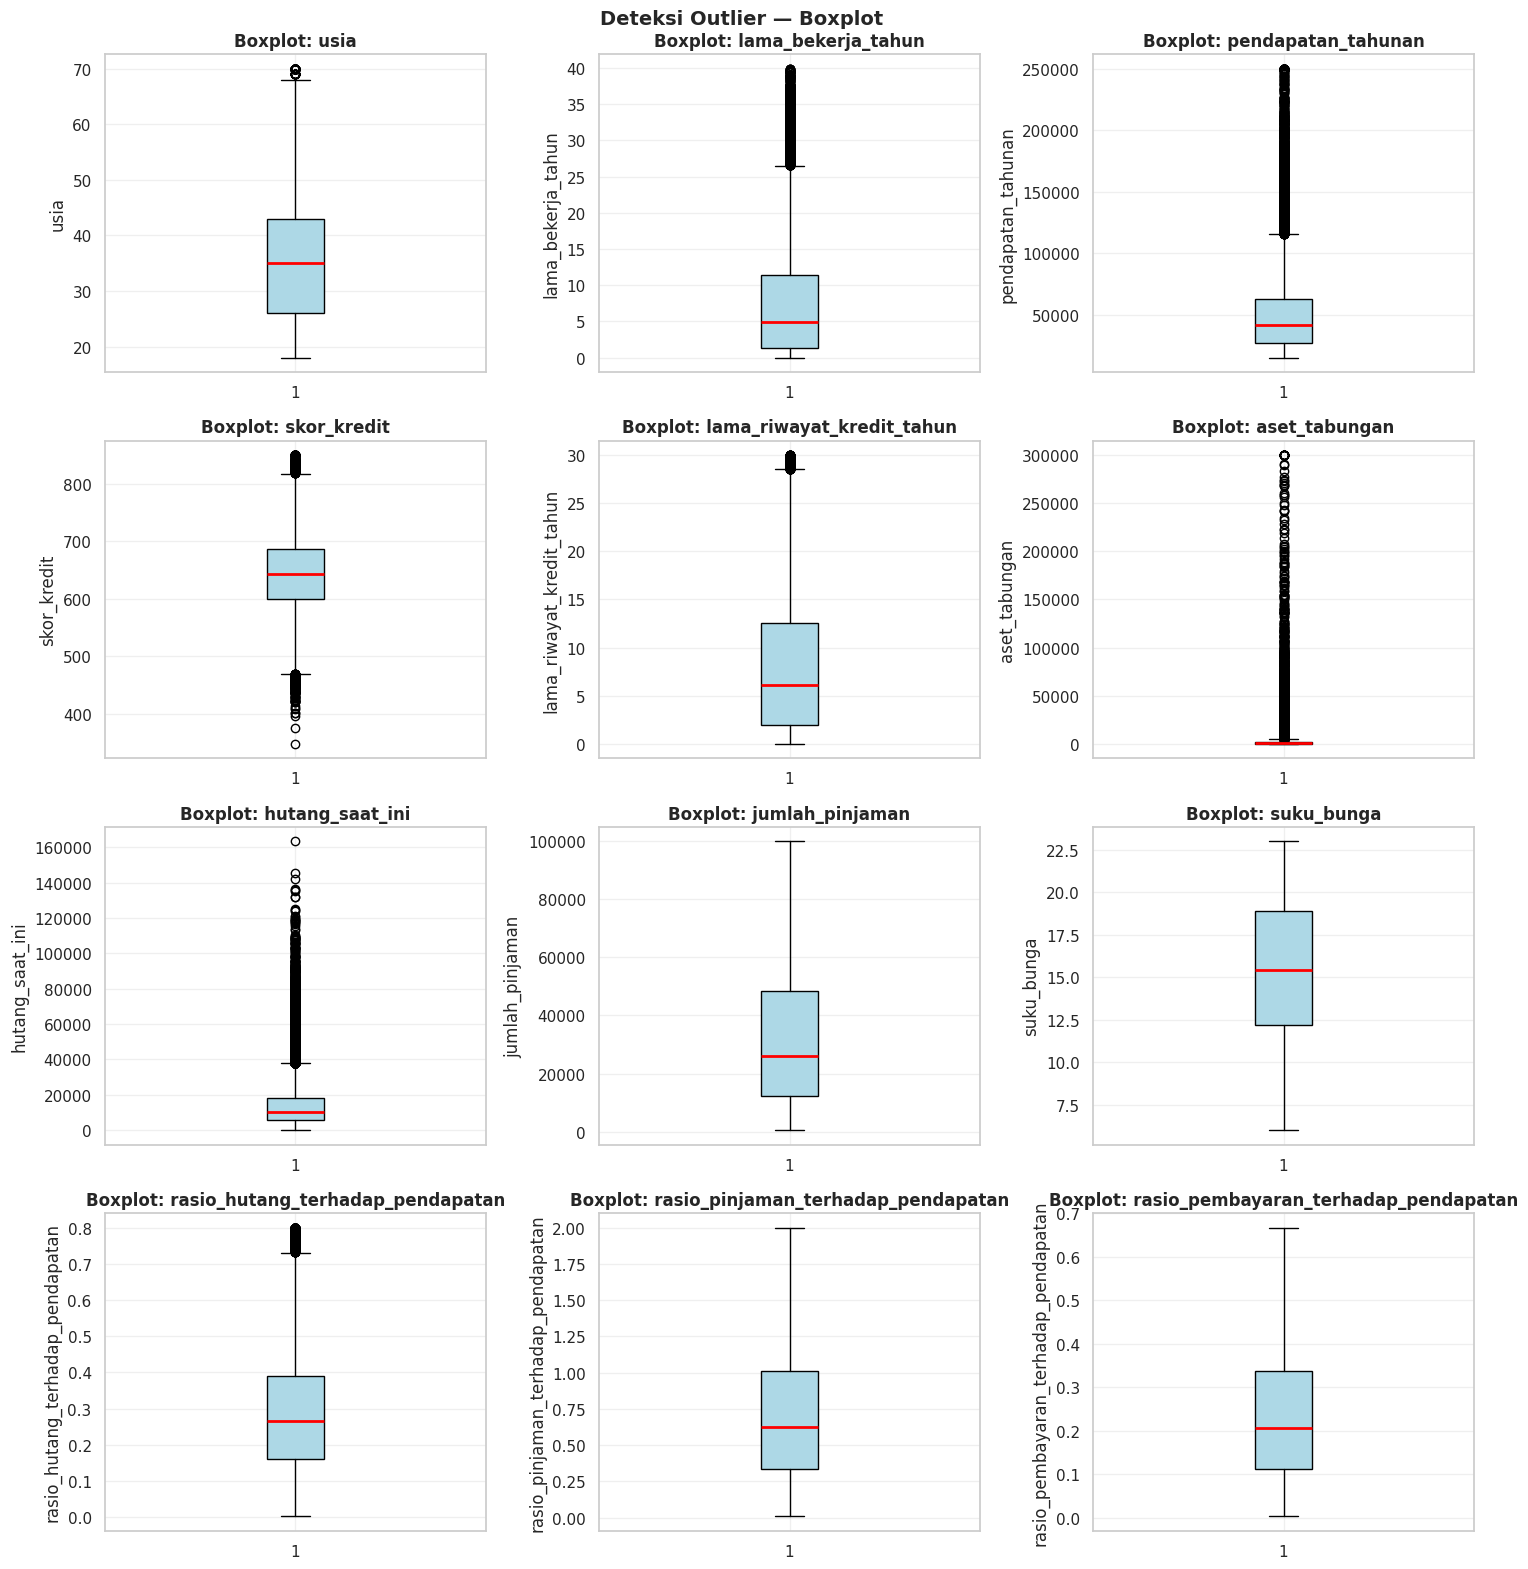

In [ ]:
# ============================================================
# 24. VISUALISASI OUTLIER — Boxplot
# ============================================================
# 🔧 SESUAIKAN: ubah cols_outlier jika ingin subset
n_cols = 3
n_rows = (len(cols_outlier) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols_outlier):
    bp = axes[i].boxplot(df[col].dropna(), patch_artist=True,
                          medianprops=dict(color='red', linewidth=2))
    bp['boxes'][0].set_facecolor('lightblue')
    axes[i].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[i].set_ylabel(col)
    axes[i].grid(True, alpha=0.3)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Deteksi Outlier — Boxplot', fontsize=14,
             fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 25. PENANGANAN OUTLIER
# ============================================================

# Memilih kolom yang akan ditangani outliernya berdasarkan hasil analisis skewness dan kurtosis.
# 'aset_tabungan' (skewness ≈ 12), 'hutang_saat_ini', 'pendapatan_tahunan', dan 'jumlah_pinjaman'
# memiliki skala nilai yang sangat bervariasi (dari puluhan hingga ratusan ribu), sehingga
# berpotensi mengandung outlier yang signifikan dan perlu ditangani.
COLS_HANDLE_OUTLIER = ['pendapatan_tahunan', 'aset_tabungan', 'hutang_saat_ini', 'jumlah_pinjaman']  # 🔧 SESUAIKAN kolom yang ingin ditangani outliernya

## ===== OPSI A: HAPUS baris yang mengandung outlier (IQR) =====
# idx_to_drop = set()
# for col in COLS_HANDLE_OUTLIER:
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1
#     mask = (df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)
#     idx_to_drop.update(df[mask].index.tolist())
# print(f"Akan dihapus {len(idx_to_drop)} baris outlier")
# df = df.drop(index=list(idx_to_drop)).reset_index(drop=True)
# print(f"✅ Dimensi setelah hapus outlier: {df.shape}")

## ===== OPSI B: WINSORIZING — ganti outlier dengan batas IQR =====
# Winsorizing adalah metode yang lebih aman daripada menghapus baris, karena mempertahankan ukuran dataset
# (sesuai Aturan & Etika Jobsheet: menyimpan jumlah baris tetap utuh / no data loss).
for col in COLS_HANDLE_OUTLIER:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        before = ((df[col] < lower) | (df[col] > upper)).sum()
        if before > 0:
            df[col] = df[col].clip(lower=lower, upper=upper)
            print(f"✅ '{col}': {before} outlier di-winsorize ke [{lower:.2f}, {upper:.2f}]")
        else:
            print(f"ℹ️ '{col}': Tidak ada outlier yang perlu di-winsorize.")

## ===== OPSI C: TRANSFORMASI LOG (untuk distribusi sangat miring) =====
# df['aset_tabungan_log'] = np.log1p(df['aset_tabungan'])  # log(1+x) aman untuk 0
# print("✅ Kolom 'aset_tabungan_log' berhasil dibuat (log transform)")

print("✅ Penanganan outlier selesai!")
print(f"Dimensi dataset saat ini: {df.shape}")


✅ 'pendapatan_tahunan': 2355 outlier di-winsorize ke [-25883.62, 115887.38]
✅ 'aset_tabungan': 6508 outlier di-winsorize ke [-3081.50, 5482.50]
✅ 'hutang_saat_ini': 2932 outlier di-winsorize ke [-13721.38, 37751.62]
ℹ️ 'jumlah_pinjaman': Tidak ada outlier yang perlu di-winsorize.
✅ Penanganan outlier selesai!
Dimensi dataset saat ini: (50000, 20)


# CORRELATION ANALYSIS — Pearson, Spearman, Kendall

In [ ]:
# ============================================================
# 26. CORRELATION ANALYSIS — Pearson, Spearman, Kendall
# ============================================================

# 🔧 SESUAIKAN: kolom numerik untuk korelasi — seluruh fitur numerik disertakan
# (termasuk target 'status_pinjaman' agar terlihat korelasinya terhadap fitur lain)
cols_corr = df.select_dtypes(include=np.number).columns.tolist()

print("--- Pearson (asumsi distribusi normal, data kontinu) ---")
corr_pearson = df[cols_corr].corr(method='pearson')
display(corr_pearson.round(3))

print("--- Spearman (data ordinal / tidak normal) ---")
corr_spearman = df[cols_corr].corr(method='spearman')
display(corr_spearman.round(3))

print("--- Kendall (data kecil / banyak ties) ---")
corr_kendall = df[cols_corr].corr(method='kendall')
display(corr_kendall.round(3))


--- Pearson (asumsi distribusi normal, data kontinu) ---


,usia,lama_bekerja_tahun,pendapatan_tahunan,skor_kredit,lama_riwayat_kredit_tahun,aset_tabungan,hutang_saat_ini,gagal_bayar_tercatat,tunggakan_2thn_terakhir,catatan_negatif,jumlah_pinjaman,suku_bunga,rasio_hutang_terhadap_pendapatan,rasio_pinjaman_terhadap_pendapatan,rasio_pembayaran_terhadap_pendapatan,status_pinjaman
usia,1.0000,0.6260,0.2880,0.3680,0.6350,0.3720,0.2000,-0.0640,-0.1010,-0.0990,0.1720,-0.1880,-0.0090,-0.0390,-0.0390,0.3110
lama_bekerja_tahun,0.6260,1.0000,0.2620,0.2350,0.4050,0.2650,0.1830,-0.0410,-0.0640,-0.0660,0.1850,-0.1230,-0.0040,0.0180,0.0180,0.2190
pendapatan_tahunan,0.2880,0.2620,1.0000,0.1910,0.1800,0.3480,0.6860,-0.0390,-0.0520,-0.0470,0.5540,-0.0980,-0.0010,-0.1190,-0.1190,0.1630
skor_kredit,0.3680,0.2350,0.1910,1.0000,0.2370,0.1650,0.1310,-0.1890,-0.2840,-0.2680,0.1120,-0.4930,-0.0050,-0.0190,-0.0190,0.4960
lama_riwayat_kredit_tahun,0.6350,0.4050,0.1800,0.2370,1.0000,0.4970,0.1280,-0.0450,-0.0640,-0.0640,0.1070,-0.1240,-0.0010,-0.0250,-0.0250,0.2770
aset_tabungan,0.3720,0.2650,0.3480,0.1650,0.4970,1.0000,0.2460,-0.0330,-0.0470,-0.0430,0.2100,-0.0840,0.0030,-0.0330,-0.0330,0.1910
hutang_saat_ini,0.2000,0.1830,0.6860,0.1310,0.1280,0.2460,1.0000,-0.0260,-0.0350,-0.0350,0.3880,-0.0640,0.6500,-0.0780,-0.0780,-0.0830
gagal_bayar_tercatat,-0.0640,-0.0410,-0.0390,-0.1890,-0.0450,-0.0330,-0.0260,1.0000,0.2520,0.0980,-0.0190,0.1050,-0.0020,0.0060,0.0060,-0.2630
tunggakan_2thn_terakhir,-0.1010,-0.0640,-0.0520,-0.2840,-0.0640,-0.0470,-0.0350,0.2520,1.0000,0.0800,-0.0290,0.1630,0.0020,0.0050,0.0050,-0.3180
catatan_negatif,-0.0990,-0.0660,-0.0470,-0.2680,-0.0640,-0.0430,-0.0350,0.0980,0.0800,1.0000,-0.0240,0.1420,-0.0070,0.0070,0.0070,-0.2250


--- Spearman (data ordinal / tidak normal) ---


,usia,lama_bekerja_tahun,pendapatan_tahunan,skor_kredit,lama_riwayat_kredit_tahun,aset_tabungan,hutang_saat_ini,gagal_bayar_tercatat,tunggakan_2thn_terakhir,catatan_negatif,jumlah_pinjaman,suku_bunga,rasio_hutang_terhadap_pendapatan,rasio_pinjaman_terhadap_pendapatan,rasio_pembayaran_terhadap_pendapatan,status_pinjaman
usia,1.0000,0.6410,0.3090,0.3580,0.6620,0.4560,0.1990,-0.0640,-0.1060,-0.0990,0.1690,-0.1790,-0.0080,-0.0320,-0.0320,0.3150
lama_bekerja_tahun,0.6410,1.0000,0.3370,0.2340,0.4580,0.3580,0.2180,-0.0460,-0.0660,-0.0700,0.2350,-0.1200,-0.0060,0.0480,0.0480,0.2480
pendapatan_tahunan,0.3090,0.3370,1.0000,0.1860,0.2050,0.3880,0.6570,-0.0360,-0.0550,-0.0470,0.5810,-0.0950,-0.0020,-0.0380,-0.0380,0.1620
skor_kredit,0.3580,0.2340,0.1860,1.0000,0.2360,0.1900,0.1200,-0.1940,-0.3180,-0.2720,0.1050,-0.4870,-0.0050,-0.0170,-0.0170,0.5140
lama_riwayat_kredit_tahun,0.6620,0.4580,0.2050,0.2360,1.0000,0.6260,0.1350,-0.0480,-0.0660,-0.0670,0.1100,-0.1190,-0.0020,-0.0220,-0.0220,0.3030
aset_tabungan,0.4560,0.3580,0.3880,0.1900,0.6260,1.0000,0.2610,-0.0380,-0.0580,-0.0520,0.2260,-0.0950,0.0040,-0.0220,-0.0220,0.2270
hutang_saat_ini,0.1990,0.2180,0.6570,0.1200,0.1350,0.2610,1.0000,-0.0270,-0.0340,-0.0330,0.3810,-0.0580,0.7160,-0.0330,-0.0330,-0.0740
gagal_bayar_tercatat,-0.0640,-0.0460,-0.0360,-0.1940,-0.0480,-0.0380,-0.0270,1.0000,0.2130,0.0960,-0.0190,0.1020,-0.0030,0.0060,0.0060,-0.2630
tunggakan_2thn_terakhir,-0.1060,-0.0660,-0.0550,-0.3180,-0.0660,-0.0580,-0.0340,0.2130,1.0000,0.0810,-0.0330,0.1650,0.0040,0.0020,0.0020,-0.2990
catatan_negatif,-0.0990,-0.0700,-0.0470,-0.2720,-0.0670,-0.0520,-0.0330,0.0960,0.0810,1.0000,-0.0250,0.1380,-0.0050,0.0050,0.0050,-0.2230


--- Kendall (data kecil / banyak ties) ---


,usia,lama_bekerja_tahun,pendapatan_tahunan,skor_kredit,lama_riwayat_kredit_tahun,aset_tabungan,hutang_saat_ini,gagal_bayar_tercatat,tunggakan_2thn_terakhir,catatan_negatif,jumlah_pinjaman,suku_bunga,rasio_hutang_terhadap_pendapatan,rasio_pinjaman_terhadap_pendapatan,rasio_pembayaran_terhadap_pendapatan,status_pinjaman
usia,1.0000,0.4920,0.2140,0.2470,0.5000,0.3200,0.1360,-0.0530,-0.0840,-0.0820,0.1150,-0.1220,-0.0050,-0.0220,-0.0220,0.2610
lama_bekerja_tahun,0.4920,1.0000,0.2280,0.1580,0.3240,0.2460,0.1470,-0.0380,-0.0520,-0.0570,0.1580,-0.0810,-0.0040,0.0320,0.0320,0.2030
pendapatan_tahunan,0.2140,0.2280,1.0000,0.1250,0.1390,0.2670,0.4760,-0.0290,-0.0430,-0.0380,0.4100,-0.0640,-0.0010,-0.0290,-0.0290,0.1320
skor_kredit,0.2470,0.1580,0.1250,1.0000,0.1590,0.1280,0.0810,-0.1590,-0.2500,-0.2210,0.0700,-0.3680,-0.0030,-0.0110,-0.0110,0.4210
lama_riwayat_kredit_tahun,0.5000,0.3240,0.1390,0.1590,1.0000,0.4500,0.0900,-0.0390,-0.0520,-0.0540,0.0740,-0.0790,-0.0010,-0.0150,-0.0150,0.2480
aset_tabungan,0.3200,0.2460,0.2670,0.1280,0.4500,1.0000,0.1770,-0.0310,-0.0460,-0.0430,0.1530,-0.0640,0.0030,-0.0150,-0.0150,0.1870
hutang_saat_ini,0.1360,0.1470,0.4760,0.0810,0.0900,0.1770,1.0000,-0.0220,-0.0270,-0.0270,0.2600,-0.0390,0.5250,-0.0230,-0.0230,-0.0600
gagal_bayar_tercatat,-0.0530,-0.0380,-0.0290,-0.1590,-0.0390,-0.0310,-0.0220,1.0000,0.2040,0.0960,-0.0150,0.0830,-0.0020,0.0050,0.0050,-0.2630
tunggakan_2thn_terakhir,-0.0840,-0.0520,-0.0430,-0.2500,-0.0520,-0.0460,-0.0270,0.2040,1.0000,0.0770,-0.0260,0.1300,0.0030,0.0010,0.0010,-0.2860
catatan_negatif,-0.0820,-0.0570,-0.0380,-0.2210,-0.0540,-0.0430,-0.0270,0.0960,0.0770,1.0000,-0.0200,0.1110,-0.0040,0.0040,0.0040,-0.2210


Interpretasi Koefisien Korelasi:
> |r| = 0.00–0.19 : Sangat lemah / Tidak ada korelasi

> |r| = 0.20–0.39 : Lemah

> |r| = 0.40–0.59 : Sedang

>|r| = 0.60–0.79 : Kuat

> |r| = 0.80–1.00 : Sangat kuat

> r > 0 : Korelasi positif (searah)

> r < 0 : Korelasi negatif (berlawanan arah)

# CROSSTAB ANALYSIS

📊 Crosstab: 'status_pekerjaan' × 'status_pinjaman'


status_pinjaman,0,1,Total
status_pekerjaan,,,
Bekerja,15977,19029,35006
Mahasiswa,2123,2717,4840
Wiraswasta,4377,5777,10154
Total,22477,27523,50000


  Persentase baris (%):


status_pinjaman,0,1
status_pekerjaan,,
Bekerja,45.6000,54.4000
Mahasiswa,43.9000,56.1000
Wiraswasta,43.1000,56.9000


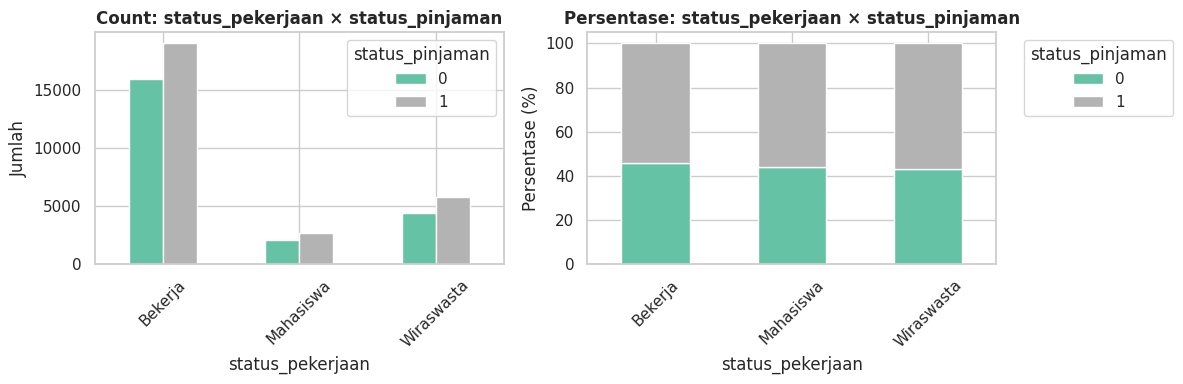

📊 Crosstab: 'tipe_produk' × 'status_pinjaman'


status_pinjaman,0,1,Total
tipe_produk,,,
Kartu Kredit,8685,13770,22455
Kredit Berjalan,4686,5336,10022
Pinjaman Pribadi,9106,8417,17523
Total,22477,27523,50000


  Persentase baris (%):


status_pinjaman,0,1
tipe_produk,,
Kartu Kredit,38.7000,61.3000
Kredit Berjalan,46.8000,53.2000
Pinjaman Pribadi,52.0000,48.0000


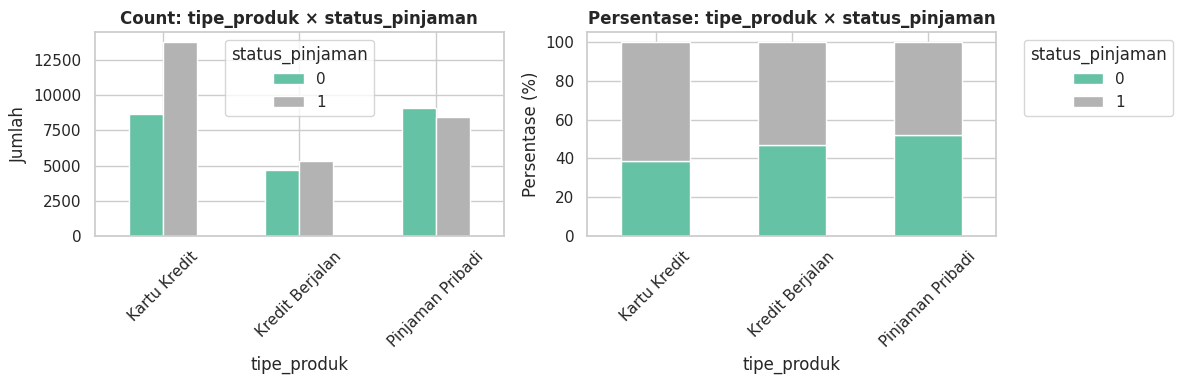

In [ ]:
# ============================================================
# 27. CROSSTAB ANALYSIS — Data Kategorikal
# ============================================================

# 🔧 SESUAIKAN: pasangan kolom kategorikal yang ingin dianalisis
CROSSTAB_PAIRS = [
    ('status_pekerjaan', 'status_pinjaman'),   # 🔧 SESUAIKAN
    ('tipe_produk',      'status_pinjaman'),   # 🔧 SESUAIKAN
]

for col_a, col_b in CROSSTAB_PAIRS:
    if col_a in df.columns and col_b in df.columns:
        print(f"📊 Crosstab: '{col_a}' × '{col_b}'")
        ct = pd.crosstab(df[col_a], df[col_b],
                          margins=True, margins_name='Total')
        display(ct)

        ct_pct = pd.crosstab(df[col_a], df[col_b], normalize='index').round(3) * 100
        print(f"  Persentase baris (%):")
        display(ct_pct)

        # Visualisasi
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        ct.drop('Total', axis=0).drop('Total', axis=1).plot(
            kind='bar', ax=axes[0], colormap='Set2', rot=45)
        axes[0].set_title(f'Count: {col_a} × {col_b}', fontweight='bold')
        axes[0].set_ylabel('Jumlah')
        axes[0].legend(title=col_b)

        ct_pct.plot(kind='bar', stacked=True, ax=axes[1],
                    colormap='Set2', rot=45)
        axes[1].set_title(f'Persentase: {col_a} × {col_b}', fontweight='bold')
        axes[1].set_ylabel('Persentase (%)')
        axes[1].legend(title=col_b, bbox_to_anchor=(1.05, 1))
        plt.tight_layout()
        plt.show()


# HEATMAP CORRELATION

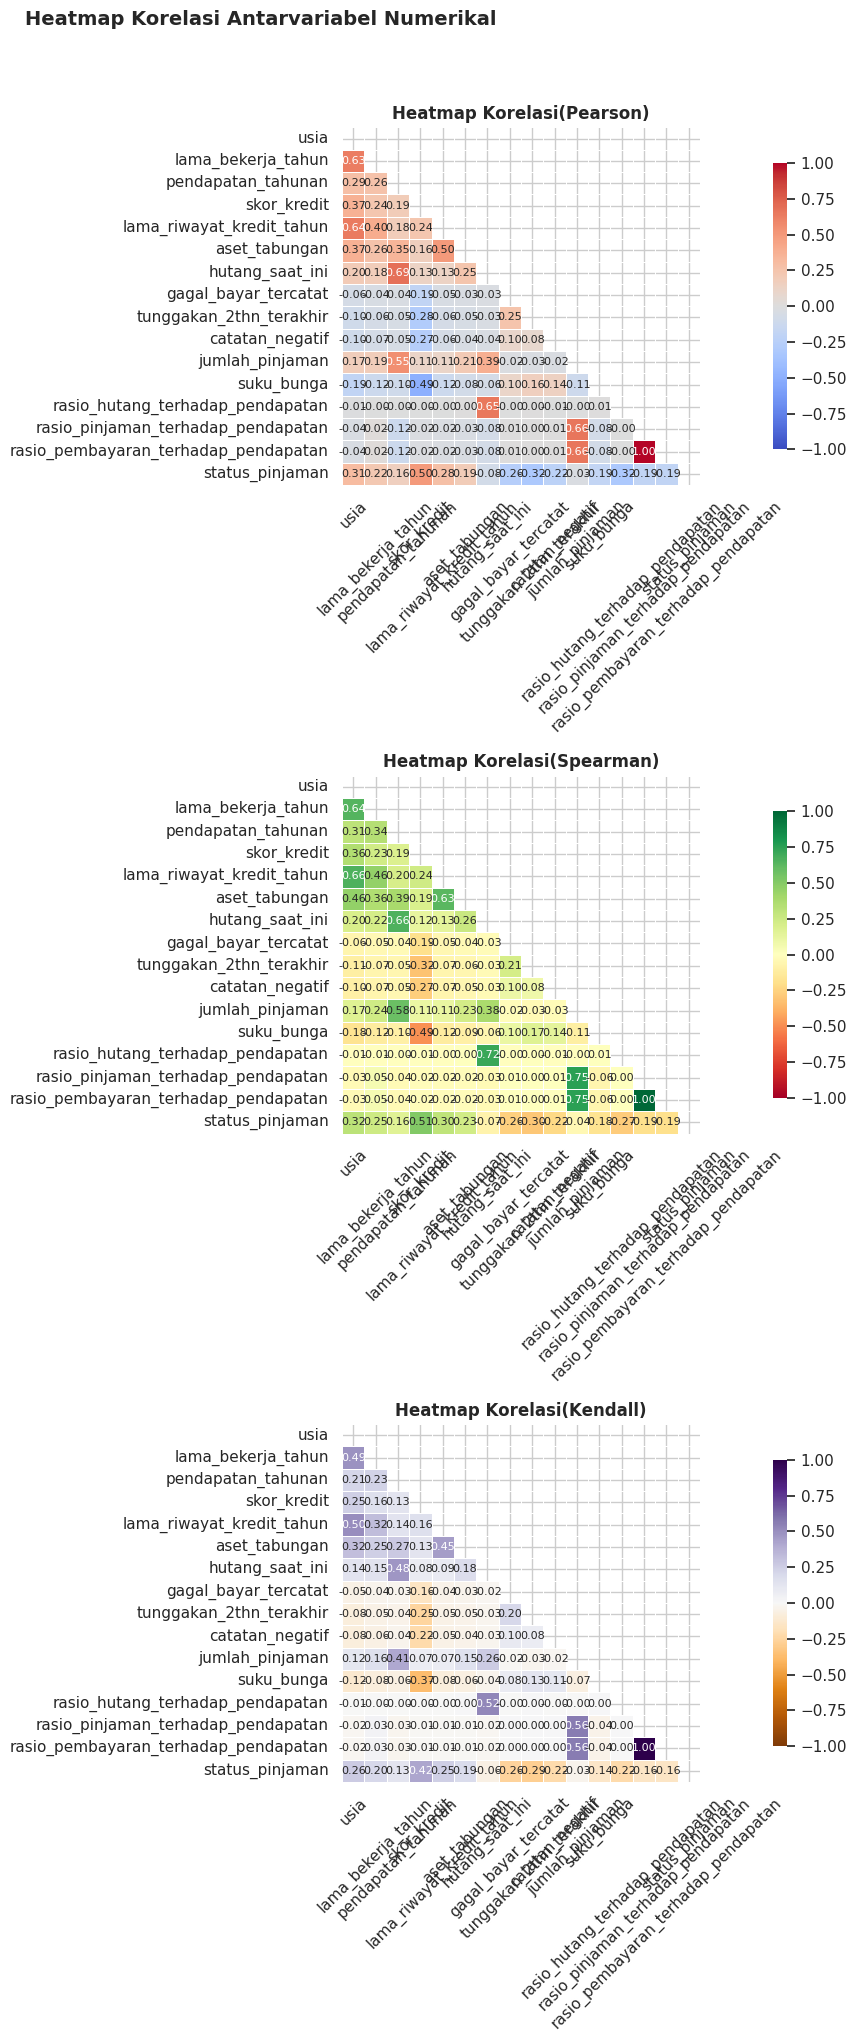

In [ ]:
# ============================================================
# 28. HEATMAP CORRELATION — Data Numerikal
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(15, 20))

metode_list = [
    ('Pearson',  corr_pearson,  'coolwarm'),
    ('Spearman', corr_spearman, 'RdYlGn'),
    ('Kendall',  corr_kendall,  'PuOr'),
]

for ax, (nama, corr_mat, cmap) in zip(axes, metode_list):
    mask = np.triu(np.ones_like(corr_mat, dtype=bool))  # Segitiga atas disembunyikan
    sns.heatmap(
        corr_mat,
        ax=ax,
        mask=mask,
        annot=True,
        fmt='.2f',
        cmap=cmap,
        center=0,
        vmin=-1, vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={'shrink': 0.8},
        annot_kws={'size': 8}
    )
    ax.set_title(f'Heatmap Korelasi({nama})', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Heatmap Korelasi Antarvariabel Numerikal',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# PAIRPLOT

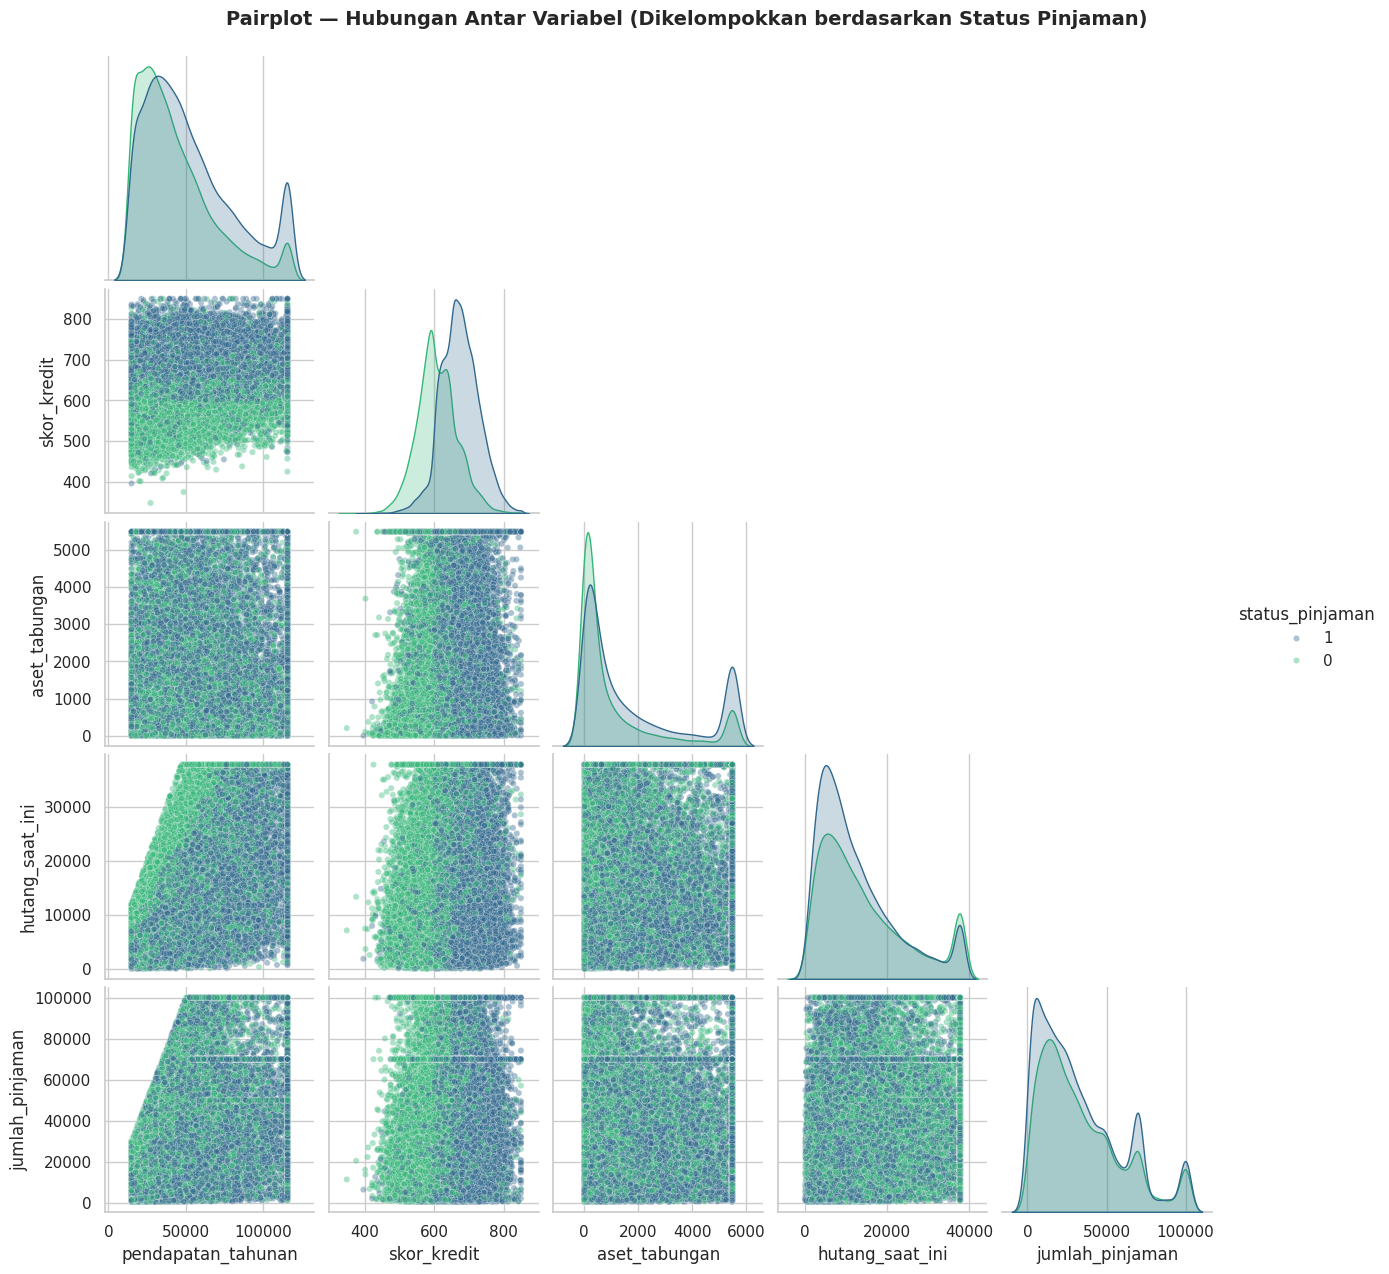

In [ ]:
# ============================================================
# 29. PAIRPLOT — Hubungan Banyak Variabel Sekaligus
# ============================================================

cols_pairplot = [
    'pendapatan_tahunan',
    'skor_kredit',
    'aset_tabungan',
    'hutang_saat_ini',
    'jumlah_pinjaman'
]  # ❦ SESUAIKAN: kolom numerik untuk pairplot

HUE_COL = 'status_pinjaman'  # ❦ SESUAIKAN 'hue' untuk pewarnaan berdasarkan kategori (set None jika tidak perlu warna)

df_pair = df[cols_pairplot].copy()
if HUE_COL and HUE_COL in df.columns:
    df_pair[HUE_COL] = df[HUE_COL].astype(str)
    # Pastikan hue column juga ada di df_pair jika ingin digunakan
    if HUE_COL not in df_pair.columns:
        df_pair = pd.concat([df_pair, df[[HUE_COL]]], axis=1)

# Drop NaN values if any, specifically for the columns being plotted and the hue column
df_pair = df_pair.dropna(subset=cols_pairplot + ([HUE_COL] if HUE_COL else [])).reset_index(drop=True)

pairplot = sns.pairplot(
    df_pair,
    hue=HUE_COL,           # ❦ SESUAIKAN
    diag_kind='kde',        # 'hist' atau 'kde'
    plot_kws={'alpha': 0.4, 's': 20},
    corner=True,            # Tampilkan sudut bawah saja
    palette='viridis',       # ❦ SESUAIKAN palette warna
)
pairplot.fig.suptitle('Pairplot — Hubungan Antar Variabel (Dikelompokkan berdasarkan Status Pinjaman)',
                       y=1.02, fontsize=14, fontweight='bold')
plt.show()


# REKAYASA FITUR

In [ ]:
# ============================================================
# 30. REKAYASA FITUR (TUGAS 4 JOBSHEET) & ENCODING DATA KATEGORIKAL
# ============================================================

# --- Rekayasa Fitur Baru (Tugas 2 & 4 Jobsheet) ---
# 1) kategori_usia — Binning/Diskretisasi usia menjadi kelompok (Muda/Dewasa/Senior)
df['kategori_usia'] = pd.cut(df['usia'], bins=[0, 30, 50, 100],
                              labels=['Muda', 'Dewasa', 'Senior'])

# 2) total_aset_neto — selisih aset tabungan dengan hutang saat ini
df['total_aset_neto'] = df['aset_tabungan'] - df['hutang_saat_ini']

# 3) rasio_aset_terhadap_pinjaman — kapasitas jaminan tabungan terhadap besar pinjaman (+1 hindari pembagian nol)
df['rasio_aset_terhadap_pinjaman'] = df['aset_tabungan'] / (df['jumlah_pinjaman'] + 1)

# 4) total_indikator_risiko — agregasi histori masalah pembayaran menjadi satu metrik
df['total_indikator_risiko'] = (df['gagal_bayar_tercatat']
                                 + df['tunggakan_2thn_terakhir']
                                 + df['catatan_negatif'])

print("✅ 4 fitur baru berhasil dibuat: kategori_usia, total_aset_neto, "
      "rasio_aset_terhadap_pinjaman, total_indikator_risiko")
display(df[['usia', 'kategori_usia', 'aset_tabungan', 'hutang_saat_ini', 'total_aset_neto',
            'jumlah_pinjaman', 'rasio_aset_terhadap_pinjaman', 'total_indikator_risiko']].head())

# --- Seleksi Fitur Non-Prediktif ---
# id_pelanggan adalah identifier unik → menambah cardinality tanpa nilai statistik prediktif → di-drop
COLS_ENCODE = ['status_pekerjaan', 'tipe_produk', 'tujuan_pinjaman', 'kategori_usia']  # ♣ SESUAIKAN

df_encoded = df.drop(columns=['id_pelanggan']).copy()  # 🔧 SESUAIKAN: kolom identifier non-prediktif

## ===== OPSI A: One-Hot Encoding (sklearn) =====
# from sklearn.preprocessing import OneHotEncoder
# ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# encoded_array = ohe.fit_transform(df_encoded[COLS_ENCODE])
# encoded_cols  = ohe.get_feature_names_out(COLS_ENCODE)
# df_ohe = pd.DataFrame(encoded_array, columns=encoded_cols)
# df_encoded = pd.concat([df_encoded.drop(columns=COLS_ENCODE).reset_index(drop=True),
#                          df_ohe.reset_index(drop=True)], axis=1)
# print("✅ One-Hot Encoding (sklearn) selesai")
# print(f"Kolom baru: {list(encoded_cols)}")

## ===== OPSI B: pd.get_dummies (lebih simpel) =====
df_encoded = pd.get_dummies(
    df_encoded,
    columns=COLS_ENCODE,
    prefix=COLS_ENCODE,
    drop_first=True,          # ♣ True = hindari dummy variable trap
    dtype=int
)
print("✅ get_dummies selesai")
print(f"Dimensi sebelum : {df.shape}")
print(f"Dimensi sesudah : {df_encoded.shape}")
print("\nKolom baru setelah encoding:")
new_cols = [c for c in df_encoded.columns if c not in df.columns]
print(new_cols)
display(df_encoded.head(3))


✅ 4 fitur baru berhasil dibuat: kategori_usia, total_aset_neto, rasio_aset_terhadap_pinjaman, total_indikator_risiko


,usia,kategori_usia,aset_tabungan,hutang_saat_ini,total_aset_neto,jumlah_pinjaman,rasio_aset_terhadap_pinjaman,total_indikator_risiko
0,40.0000,Dewasa,895.0000,10820.0000,-9925.0000,600,1.4892,0
1,33.0000,Dewasa,169.0000,16550.0000,-16381.0000,53300,0.0032,1
2,42.0000,Dewasa,17.0000,7852.0000,-7835.0000,2100,0.0081,0
3,53.0000,Senior,1480.0000,11603.0000,-10123.0000,2900,0.5102,1
4,32.0000,Dewasa,209.0000,12424.0000,-12215.0000,99600,0.0021,0


✅ get_dummies selesai
Dimensi sebelum : (50000, 24)
Dimensi sesudah : (50000, 30)

Kolom baru setelah encoding:
['status_pekerjaan_Mahasiswa', 'status_pekerjaan_Wiraswasta', 'tipe_produk_Kredit Berjalan', 'tipe_produk_Pinjaman Pribadi', 'tujuan_pinjaman_Konsolidasi Hutang', 'tujuan_pinjaman_Medis', 'tujuan_pinjaman_Pendidikan', 'tujuan_pinjaman_Pribadi', 'tujuan_pinjaman_Renovasi Rumah', 'kategori_usia_Dewasa', 'kategori_usia_Senior']


,usia,lama_bekerja_tahun,pendapatan_tahunan,skor_kredit,lama_riwayat_kredit_tahun,aset_tabungan,hutang_saat_ini,gagal_bayar_tercatat,tunggakan_2thn_terakhir,catatan_negatif,jumlah_pinjaman,suku_bunga,rasio_hutang_terhadap_pendapatan,rasio_pinjaman_terhadap_pendapatan,rasio_pembayaran_terhadap_pendapatan,status_pinjaman,total_aset_neto,rasio_aset_terhadap_pinjaman,total_indikator_risiko,status_pekerjaan_Mahasiswa,status_pekerjaan_Wiraswasta,tipe_produk_Kredit Berjalan,tipe_produk_Pinjaman Pribadi,tujuan_pinjaman_Konsolidasi Hutang,tujuan_pinjaman_Medis,tujuan_pinjaman_Pendidikan,tujuan_pinjaman_Pribadi,tujuan_pinjaman_Renovasi Rumah,kategori_usia_Dewasa,kategori_usia_Senior
0,40.0000,17.2000,25579.0000,692,5.3000,895.0000,10820.0000,0,0,0,600,17.0200,0.4230,0.0230,0.0080,1,-9925.0000,1.4892,0,0,0,0,0,0,0,0,0,0,1,0
1,33.0000,7.3000,43087.0000,627,3.5000,169.0000,16550.0000,0,1,0,53300,14.1000,0.3840,1.2370,0.4120,0,-16381.0000,0.0032,1,0,0,0,1,0,0,0,0,1,1,0
2,42.0000,1.1000,20840.0000,689,8.4000,17.0000,7852.0000,0,0,0,2100,18.3300,0.3770,0.1010,0.0340,1,-7835.0000,0.0081,0,1,0,0,0,1,0,0,0,0,1,0


# Scalling


In [ ]:
# ============================================================
# 31. SCALING DATA NUMERIKAL
# ============================================================
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

COLS_SCALE = [
    'usia', 'lama_bekerja_tahun', 'pendapatan_tahunan', 'skor_kredit',
    'lama_riwayat_kredit_tahun', 'aset_tabungan', 'hutang_saat_ini',
    'jumlah_pinjaman', 'suku_bunga', 'rasio_hutang_terhadap_pendapatan',
    'rasio_pinjaman_terhadap_pendapatan', 'rasio_pembayaran_terhadap_pendapatan',
    'total_aset_neto', 'rasio_aset_terhadap_pinjaman', 'total_indikator_risiko'
]  # ♣ SESUAIKAN kolom numerik yang perlu di-scale

print("Statistik sebelum scaling:")
display(df_encoded[COLS_SCALE].describe().T[['mean', 'std', 'min', 'max']])

## ===== OPSI A: StandardScaler (mean=0, std=1) — cocok jika normal =====
# 🔧 SESUAIKAN: sesuai Tugas 5 Jobsheet — Standardisasi Z-Score (StandardScaler) dipilih
# karena cocok untuk mayoritas model ML (KNN, SVM, Logistic Regression berbasis jarak).
scaler = StandardScaler()

df_scaled = df_encoded.copy()
df_scaled[COLS_SCALE] = scaler.fit_transform(df_scaled[COLS_SCALE])

print("\nStatistik setelah Standardisasi (StandardScaler):")
display(df_scaled[COLS_SCALE].describe().T[['mean', 'std', 'min', 'max']])
print("✅ Scaling selesai!")

## ===== OPSI B: MinMaxScaler (0–1) — cocok jika tahu batas =====
# scaler = MinMaxScaler()

# df_scaled = df_encoded.copy()
# df_scaled[COLS_SCALE] = scaler.fit_transform(df_scaled[COLS_SCALE])

# print("Statistik setelah MinMaxScaling:")
# display(df_scaled[COLS_SCALE].describe().T[['mean', 'std', 'min', 'max']])
# print("✅ Scaling selesai!")

## ===== OPSI C: RobustScaler (median-based) — cocok jika banyak outlier =====
# scaler = RobustScaler()

# df_scaled = df_encoded.copy()
# df_scaled[COLS_SCALE] = scaler.fit_transform(df_scaled[COLS_SCALE])

# print("\nStatistik setelah RobustScaling:")
# display(df_scaled[COLS_SCALE].describe().T[['mean', 'std', 'min', 'max']])
# print("✅ Scaling selesai!")


Statistik sebelum scaling:


,mean,std,min,max
usia,34.9572,11.0988,18.0000,70.0000
lama_bekerja_tahun,7.4549,7.6121,0.0000,39.9000
pendapatan_tahunan,48476.9543,27420.8002,15000.0000,115887.3750
skor_kredit,643.6148,64.7315,348.0000,850.0000
lama_riwayat_kredit_tahun,8.1683,7.2076,0.0000,30.0000
aset_tabungan,1530.0220,1902.9646,0.0000,5482.5000
hutang_saat_ini,13385.5849,10163.2623,60.0000,37751.6250
jumlah_pinjaman,33041.8740,26116.1851,500.0000,100000.0000
suku_bunga,15.4986,4.0679,6.0000,23.0000
rasio_hutang_terhadap_pendapatan,0.2857,0.1598,0.0020,0.8000



Statistik setelah Standardisasi (StandardScaler):


,mean,std,min,max
usia,-0.0000,1.0000,-1.5279,3.1574
lama_bekerja_tahun,-0.0000,1.0000,-0.9794,4.2624
pendapatan_tahunan,-0.0000,1.0000,-1.2209,2.4584
skor_kredit,-0.0000,1.0000,-4.5668,3.1884
lama_riwayat_kredit_tahun,-0.0000,1.0000,-1.1333,3.0290
aset_tabungan,-0.0000,1.0000,-0.8040,2.0770
hutang_saat_ini,0.0000,1.0000,-1.3112,2.3975
jumlah_pinjaman,-0.0000,1.0000,-1.2461,2.5639
suku_bunga,-0.0000,1.0000,-2.3350,1.8440
rasio_hutang_terhadap_pendapatan,-0.0000,1.0000,-1.7757,3.2186


✅ Scaling selesai!


,Fitur,Importance,Rank,Kumulatif (%)
0,skor_kredit,0.2003,1,20.0300
1,rasio_hutang_terhadap_pendapatan,0.1626,2,36.2900
2,total_indikator_risiko,0.0582,3,42.1000
3,suku_bunga,0.0557,4,47.6800
4,lama_riwayat_kredit_tahun,0.0532,5,52.9900
5,rasio_pinjaman_terhadap_pendapatan,0.0444,6,57.4300
6,usia,0.0404,7,61.4800
7,rasio_pembayaran_terhadap_pendapatan,0.0386,8,65.3300
8,lama_bekerja_tahun,0.0354,9,68.8700
9,tunggakan_2thn_terakhir,0.0337,10,72.2400


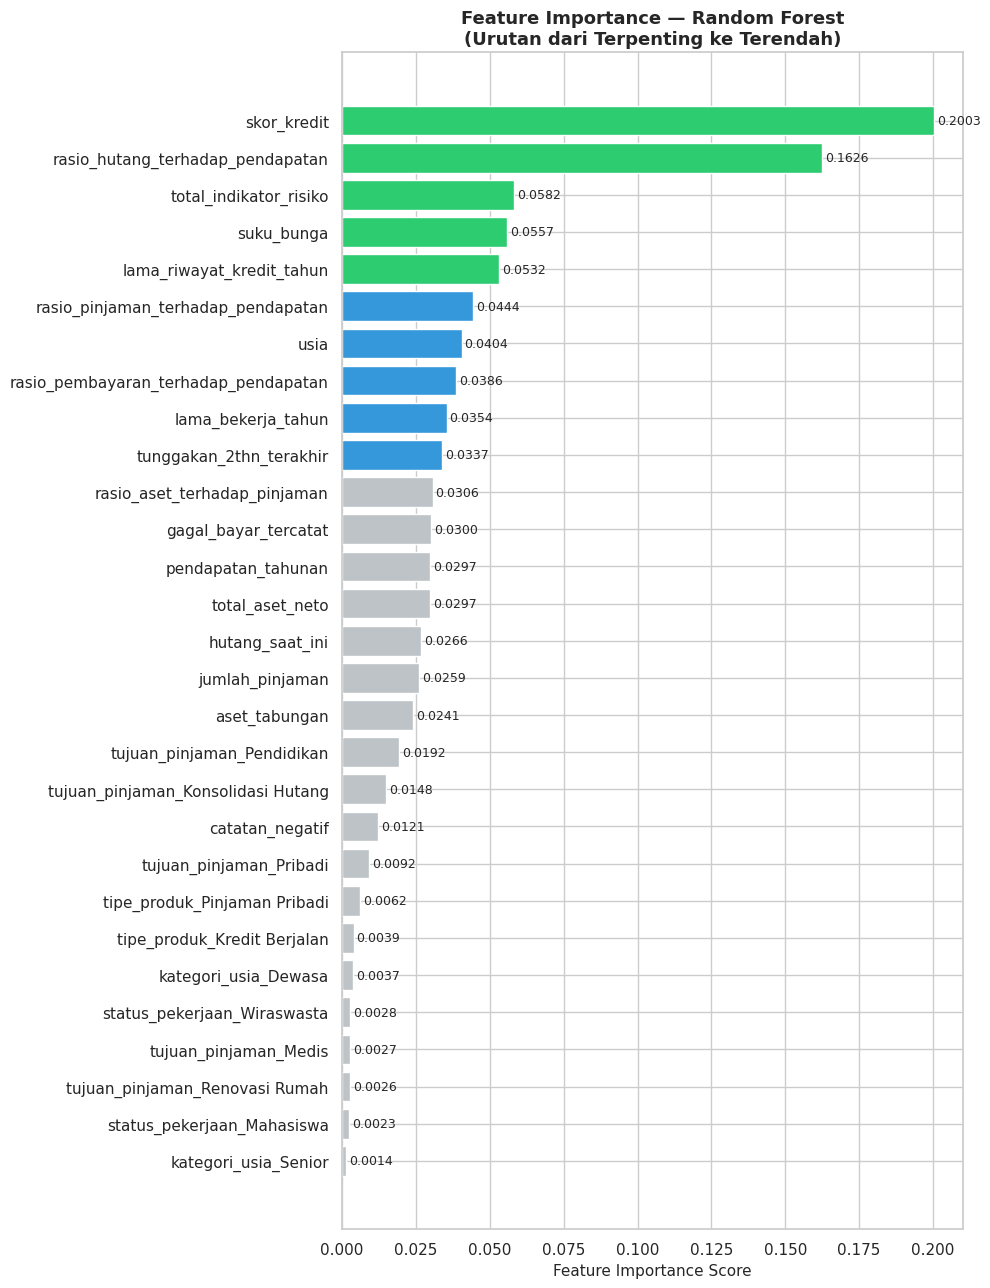

✅ Fitur terpenting hingga terendah telah diurutkan!


In [ ]:
# ============================================================
# 32. FEATURE SELECTION — Urutan Fitur Terpenting
# ============================================================
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

TARGET_COL  = 'status_pinjaman'   # ♣ SESUAIKAN nama kolom target
TASK_TYPE   = 'classification'    # ♣ SESUAIKAN: 'classification' atau 'regression'

## Siapkan fitur
all_numeric_cols = df_scaled.select_dtypes(include=np.number).columns.tolist()
cols_fs = [c for c in all_numeric_cols
           if c not in [TARGET_COL]]

X = df_scaled[cols_fs].fillna(0)  # ♣ SESUAIKAN nama dataframe yang aktif terakhir kali df_encoded atau df jika tidak melalui proses apapun
y = df_scaled[TARGET_COL].fillna(0)


if TASK_TYPE == 'classification':
    # Pastikan y adalah integer untuk klasifikasi
    y = y.astype(int)
    model_fs = RandomForestClassifier(n_estimators=100, random_state=42) # ♣ SESUAIKAN algoritmanya
else:
    model_fs = RandomForestRegressor(n_estimators=100, random_state=42)

model_fs.fit(X, y)

## Buat dataframe importance
importance_df = pd.DataFrame({
    'Fitur'     : cols_fs,
    'Importance': model_fs.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)
importance_df['Rank'] = importance_df.index + 1
importance_df['Kumulatif (%)'] = (importance_df['Importance'].cumsum() * 100).round(2)

display(importance_df)

## Visualisasi
plt.figure(figsize=(10, max(4, len(cols_fs) * 0.45)))
colors = ['#2ecc71' if i < 5 else '#3498db' if i < 10 else '#bdc3c7'
          for i in range(len(importance_df))]
bars = plt.barh(importance_df['Fitur'][::-1],
                importance_df['Importance'][::-1],
                color=colors[::-1], edgecolor='white')
plt.xlabel('Feature Importance Score', fontsize=11)
plt.title('Feature Importance — Random Forest\n(Urutan dari Terpenting ke Terendah)',
          fontsize=13, fontweight='bold')
for bar, val in zip(bars, importance_df['Importance'][::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()
print("✅ Fitur terpenting hingga terendah telah diurutkan!")


---
# VISUALISASI DATA
> Setiap sel di bawah merupakan jenis grafik yang berdiri sendiri dan bisa dijalankan secara independen.

> Sesuaikan parameter bertanda `# 🔧 SESUAIKAN` untuk tiap grafik.

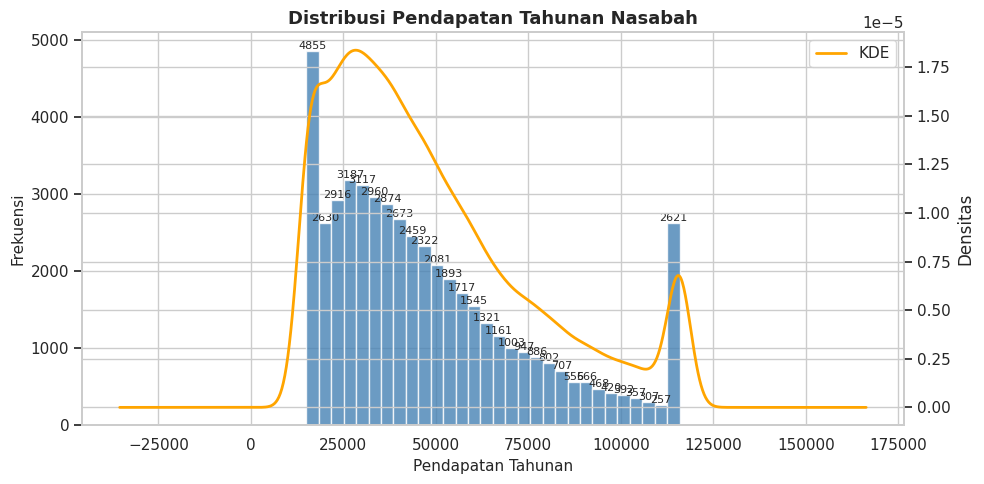

In [ ]:
# ============================================================
# 33A. HISTOGRAM
# ============================================================
# Mengatasi kemungkinan error Matplotlib dengan membuat figure dan axes secara eksplisit.
# `plt.figure()` terkadang mengalami masalah internal yang menyebabkan TypeError
# dengan dimensi yang sangat besar. Menggunakan `plt.subplots()` dan mengarahkan
# plotting ke `ax` dapat memberikan kontrol yang lebih baik.
fig, ax = plt.subplots(figsize=(float(10), float(5))) # ⚧ SESUAIKAN ukuran (lebar, tinggi)

KOLOM_HIST    = 'pendapatan_tahunan'                     # ⚧ SESUAIKAN nama kolom
JUDUL_HIST    = 'Distribusi Pendapatan Tahunan Nasabah'  # ⚧ SESUAIKAN judul
LABEL_X_HIST  = 'Pendapatan Tahunan'                      # ⚧ SESUAIKAN label sumbu X
LABEL_Y_HIST  = 'Frekuensi'         # ⚧ SESUAIKAN label sumbu Y
WARNA_HIST    = 'steelblue'         # ⚧ SESUAIKAN warna
N_BINS        = 30                   # ⚧ SESUAIKAN jumlah bin
TAMPILKAN_KDE = True                 # ⚧ True/False untuk garis KDE
TAMPILKAN_LABEL = True               # ⚧ True/False untuk label angka

counts, bins, patches = ax.hist(
    df[KOLOM_HIST].dropna(), bins=N_BINS,
    color=WARNA_HIST, edgecolor='white', alpha=0.8
)
if TAMPILKAN_KDE:
    ax2 = ax.twinx()
    df[KOLOM_HIST].dropna().plot(kind='kde', ax=ax2, color='orange', lw=2, label='KDE')
    ax2.set_ylabel('Densitas')
    ax2.legend(loc='upper right')

if TAMPILKAN_LABEL:
    for count, patch in zip(counts, patches):
        if count > 0:
            ax.text(patch.get_x() + patch.get_width()/2, count + 0.5,
                     str(int(count)), ha='center', va='bottom', fontsize=8)

ax.set_title(JUDUL_HIST, fontsize=13, fontweight='bold')
ax.set_xlabel(LABEL_X_HIST, fontsize=11)
ax.set_ylabel(LABEL_Y_HIST, fontsize=11)
fig.tight_layout()
plt.show()


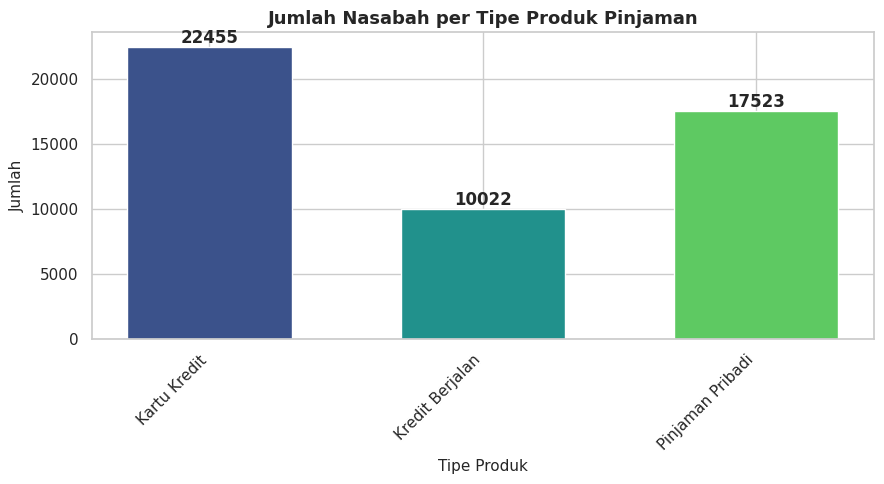

In [ ]:
# ============================================================
# 33B. BAR CHART
# ============================================================
plt.figure(figsize=(9, 5))           # ⚧ SESUAIKAN ukuran

KOLOM_BAR     = 'tipe_produk'          # ⚧ SESUAIKAN kolom kategorikal
JUDUL_BAR     = 'Jumlah Nasabah per Tipe Produk Pinjaman'  # ⚧ SESUAIKAN
LABEL_X_BAR   = 'Tipe Produk'          # ⚧ SESUAIKAN
LABEL_Y_BAR   = 'Jumlah'            # ⚧ SESUAIKAN
WARNA_BAR     = sns.color_palette('viridis', n_colors=df[KOLOM_BAR].nunique()) # ⚧ SESUAIKAN warna
LEBAR_BAR     = 0.6                  # ⚧ SESUAIKAN (0.1–1.0)
TAMPILKAN_LABEL_BAR = True           # ⚧ True/False

data_bar  = df[KOLOM_BAR].value_counts().sort_index()
bars      = plt.bar(
    data_bar.index.astype(str),
    data_bar.values,
    color=WARNA_BAR[:len(data_bar)],
    width=LEBAR_BAR,
    edgecolor='white'
)

if TAMPILKAN_LABEL_BAR:
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 str(int(bar.get_height())),
                 ha='center', va='bottom', fontweight='bold')

plt.title(JUDUL_BAR, fontsize=13, fontweight='bold')
plt.xlabel(LABEL_X_BAR, fontsize=11)
plt.ylabel(LABEL_Y_BAR, fontsize=11)
plt.xticks(rotation=45, ha='right') # Memutar label x agar tidak tumpang tindih
plt.tight_layout()
plt.show()


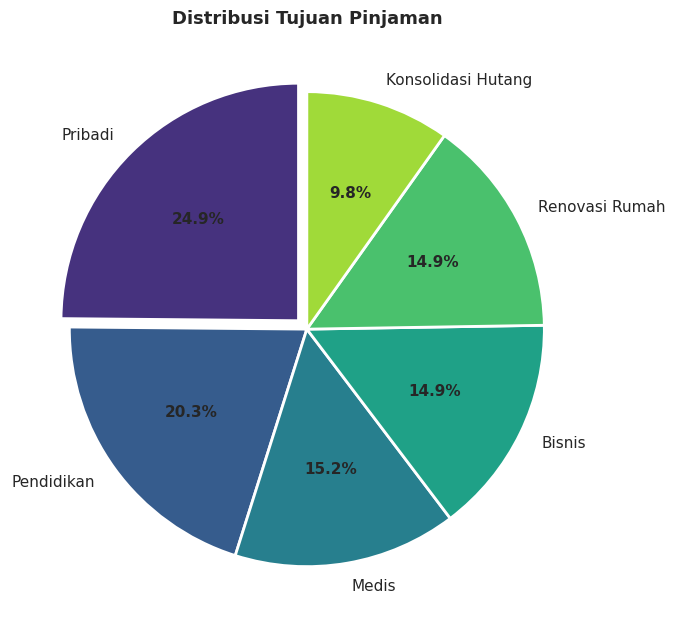

In [ ]:
# ============================================================
# 33C. PIE CHART
# ============================================================
plt.figure(figsize=(7, 7))           # ⚧ SESUAIKAN ukuran

KOLOM_PIE     = 'tujuan_pinjaman'          # ⚧ SESUAIKAN kolom
JUDUL_PIE     = 'Distribusi Tujuan Pinjaman'  # ⚧ SESUAIKAN
WARNA_PIE     = sns.color_palette('viridis', n_colors=df[KOLOM_PIE].nunique())  # ⚧ SESUAIKAN
TAMPILKAN_PCT = True                 # ⚧ True/False persen di dalam pie
TAMPILKAN_LABEL_PIE = True           # ⚧ True/False nama di luar pie

data_pie = df[KOLOM_PIE].value_counts()
EXPLODE  = tuple([0.05] + [0] * (len(data_pie) - 1))  # ⚧ SESUAIKAN — panjang harus sama dengan jumlah kategori (6)
autopct  = '%1.1f%%' if TAMPILKAN_PCT else None

wedges, texts, autotexts = plt.pie(
    data_pie.values,
    labels=data_pie.index if TAMPILKAN_LABEL_PIE else None,
    colors=WARNA_PIE[:len(data_pie)],
    autopct=autopct,
    explode=EXPLODE,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

if autotexts:
    for t in autotexts:
        t.set_fontsize(11)
        t.set_fontweight('bold')

plt.title(JUDUL_PIE, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


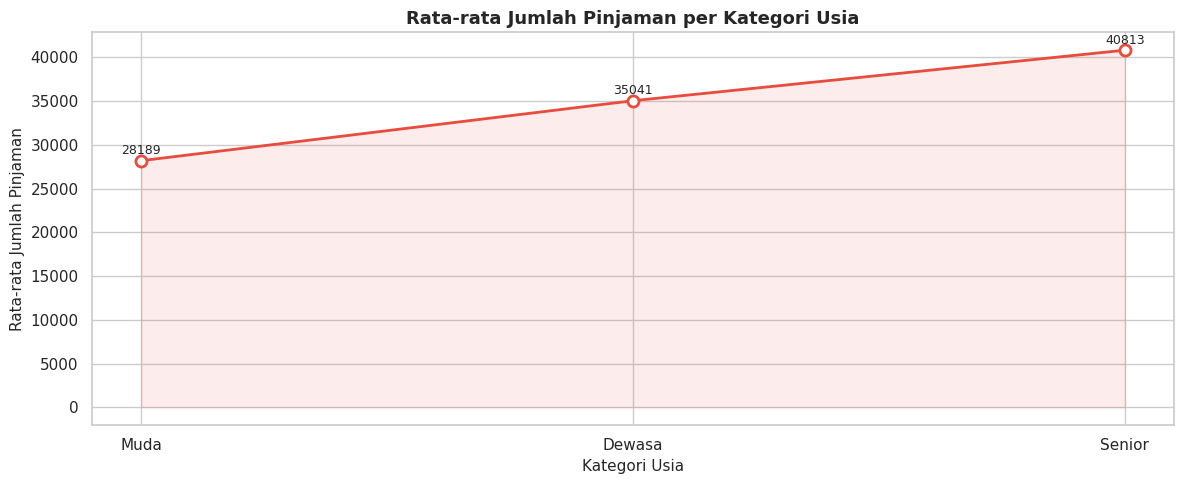

In [ ]:
# ============================================================
# 33D. LINE CHART -cocok untuk data time series
# ============================================================
# 🔧 SESUAIKAN: dataset pinjaman ini tidak memiliki dimensi waktu/tanggal, sehingga
# sumbu X digunakan untuk melihat tren rata-rata nilai pinjaman antar kelompok usia.
plt.figure(figsize=(12, 5))          # ⚧ SESUAIKAN ukuran

KOLOM_X_LINE  = 'kategori_usia'      # ⚧ SESUAIKAN sumbu X (misal tanggal/waktu)
KOLOM_Y_LINE  = 'jumlah_pinjaman'    # ⚧ SESUAIKAN sumbu Y
JUDUL_LINE    = 'Rata-rata Jumlah Pinjaman per Kategori Usia'  # ⚧ SESUAIKAN
LABEL_X_LINE  = 'Kategori Usia'      # ⚧ SESUAIKAN
LABEL_Y_LINE  = 'Rata-rata Jumlah Pinjaman'  # ⚧ SESUAIKAN
WARNA_LINE    = '#e74c3c'           # ⚧ SESUAIKAN
TEBAL_LINE    = 2.0                  # ⚧ SESUAIKAN ketebalan garis (0.5–5.0)
TAMPILKAN_MARKER = True             # ⚧ True/False untuk titik di setiap poin
TAMPILKAN_LABEL_LINE = True         # ⚧ True/False nilai di tiap titik

urutan_kategori = ['Muda', 'Dewasa', 'Senior']  # 🔧 SESUAIKAN urutan kategori agar tren terbaca logis
data_line = df.groupby(KOLOM_X_LINE, observed=True)[KOLOM_Y_LINE].mean().reindex(urutan_kategori).reset_index()

plt.plot(data_line[KOLOM_X_LINE], data_line[KOLOM_Y_LINE],
         color=WARNA_LINE, linewidth=TEBAL_LINE,
         marker='o' if TAMPILKAN_MARKER else None,
         markersize=8, markerfacecolor='white', markeredgewidth=2)

if TAMPILKAN_LABEL_LINE:
    for _, row in data_line.iterrows():
        plt.text(row[KOLOM_X_LINE], row[KOLOM_Y_LINE] + (data_line[KOLOM_Y_LINE].max() * 0.01),
                 f"{row[KOLOM_Y_LINE]:.0f}",
                 ha='center', va='bottom', fontsize=9)

plt.fill_between(data_line[KOLOM_X_LINE], data_line[KOLOM_Y_LINE],
                  alpha=0.1, color=WARNA_LINE)
plt.title(JUDUL_LINE, fontsize=13, fontweight='bold')
plt.xlabel(LABEL_X_LINE, fontsize=11)
plt.ylabel(LABEL_Y_LINE, fontsize=11)
plt.tight_layout()
plt.show()


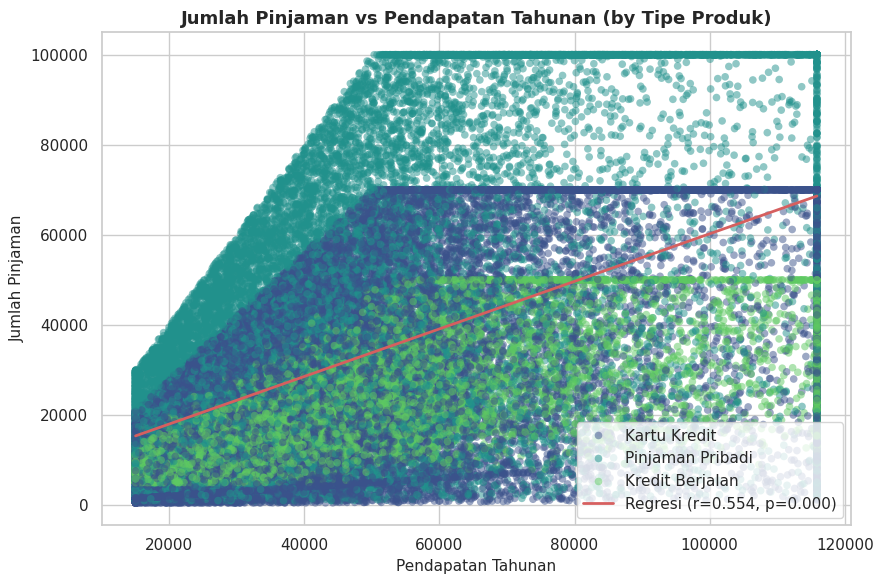

In [ ]:
# ============================================================
# 33E. SCATTER PLOT
# ============================================================
plt.figure(figsize=(9, 6))           # ⚧ SESUAIKAN ukuran

KOLOM_X_SC    = 'pendapatan_tahunan'   # ⚧ SESUAIKAN sumbu X
KOLOM_Y_SC    = 'jumlah_pinjaman'      # ⚧ SESUAIKAN sumbu Y
KOLOM_HUE_SC  = 'tipe_produk'          # ⚧ SESUAIKAN kolom warna (atau None)
JUDUL_SC      = 'Jumlah Pinjaman vs Pendapatan Tahunan (by Tipe Produk)'  # ⚧ SESUAIKAN
LABEL_X_SC    = 'Pendapatan Tahunan'   # ⚧ SESUAIKAN
LABEL_Y_SC    = 'Jumlah Pinjaman'      # ⚧ SESUAIKAN
UKURAN_TITIK  = 30                   # ⚧ SESUAIKAN ukuran titik
TRANSPARANSI  = 0.5                  # ⚧ SESUAIKAN (0=transparan, 1=solid)
TAMPILKAN_REGRESI = True            # ⚧ True/False garis regresi

if KOLOM_HUE_SC:
    scatter = sns.scatterplot(
        data=df,
        x=KOLOM_X_SC,
        y=KOLOM_Y_SC,
        hue=KOLOM_HUE_SC,
        palette='viridis',
        s=UKURAN_TITIK,
        alpha=TRANSPARANSI,
        edgecolor='none'
    )
    plt.legend(title=KOLOM_HUE_SC, bbox_to_anchor=(1.05, 1), loc='upper left')
else:
    plt.scatter(df[KOLOM_X_SC], df[KOLOM_Y_SC],
                s=UKURAN_TITIK, alpha=TRANSPARANSI,
                color='steelblue', edgecolors='none')

if TAMPILKAN_REGRESI:
    mask = df[[KOLOM_X_SC, KOLOM_Y_SC]].notna().all(axis=1)
    m, b, r, p, se = stats.linregress(df.loc[mask, KOLOM_X_SC],
                                       df.loc[mask, KOLOM_Y_SC])
    x_line = np.linspace(df[KOLOM_X_SC].min(), df[KOLOM_X_SC].max(), 100)
    plt.plot(x_line, m*x_line + b, 'r-', lw=2,
             label=f'Regresi (r={r:.3f}, p={p:.3f})')
    plt.legend(loc='upper left' if not KOLOM_HUE_SC else 'lower right') # Adjust legend position for regression

plt.title(JUDUL_SC, fontsize=13, fontweight='bold')
plt.xlabel(LABEL_X_SC, fontsize=11)
plt.ylabel(LABEL_Y_SC, fontsize=11)
plt.tight_layout()
plt.show()



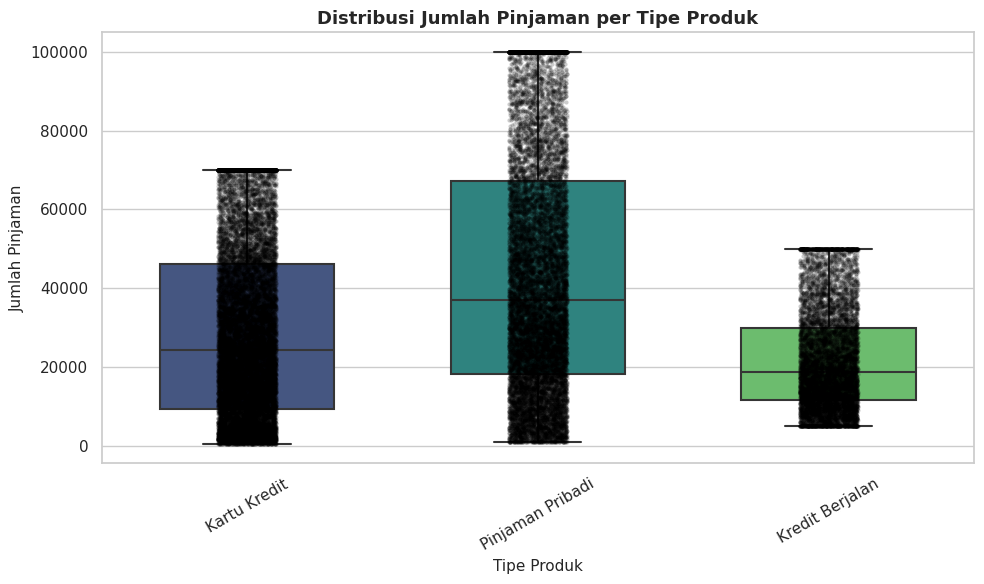

In [ ]:
# ============================================================
# 33F. BOXPLOT LENGKAP (dengan pengaturan penuh)
# ============================================================
plt.figure(figsize=(10, 6))          # ⚧ SESUAIKAN ukuran

KOLOM_BOX_Y   = 'jumlah_pinjaman'    # ⚧ SESUAIKAN kolom nilai (sumbu Y)
KOLOM_BOX_X   = 'tipe_produk'        # ⚧ SESUAIKAN kolom grup (sumbu X, atau None)
JUDUL_BOX     = 'Distribusi Jumlah Pinjaman per Tipe Produk'  # ⚧ SESUAIKAN
LABEL_X_BOX   = 'Tipe Produk'        # ⚧ SESUAIKAN
LABEL_Y_BOX   = 'Jumlah Pinjaman'    # ⚧ SESUAIKAN
WARNA_BOX     = 'viridis'             # ⚧ SESUAIKAN palette warna
LEBAR_BOX     = 0.6                 # ⚧ SESUAIKAN lebar box (0.1–1.0)
TAMPILKAN_STRIP = True             # ⚧ True/False untuk titik data individual

ax = sns.boxplot(
    data=df,
    x=KOLOM_BOX_X,
    y=KOLOM_BOX_Y,
    palette=WARNA_BOX,
    width=LEBAR_BOX,
    linewidth=1.5,
    flierprops=dict(marker='o', markersize=4, alpha=0.5)
)
if TAMPILKAN_STRIP:
    sns.stripplot(
        data=df, x=KOLOM_BOX_X, y=KOLOM_BOX_Y,
        color='black', alpha=0.2, size=3, jitter=True, ax=ax
    )

plt.title(JUDUL_BOX, fontsize=13, fontweight='bold')
plt.xlabel(LABEL_X_BOX, fontsize=11)
plt.ylabel(LABEL_Y_BOX, fontsize=11)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# RINGKASAN AKHIR EDA
# ============================================================
print("=" * 65)
print("              RINGKASAN AKHIR EDA")
print("=" * 65)
print(f"  Dimensi dataset akhir     : {df.shape[0]:,} baris x {df.shape[1]} kolom")
print(f"  Total fitur numerik        : {len(df.select_dtypes(include=np.number).columns)}")
print(f"  Total fitur kategorikal    : {len(df.select_dtypes(include=['object','category']).columns)}")
print(f"  Sisa data kosong           : {df.isnull().sum().sum()}")
print(f"  Sisa data duplikat         : {df.duplicated().sum()}")

              RINGKASAN AKHIR EDA
  Dimensi dataset akhir     : 50,000 baris x 24 kolom
  Total fitur numerik        : 19
  Total fitur kategorikal    : 5
  Sisa data kosong           : 0
  Sisa data duplikat         : 0


# X & Y

In [ ]:
# Drop 'age_group' if it's not intended as a feature for the model
df_model = df_encoded

y = df_model['status_pinjaman'] # 'churn' is now label-encoded
X = df_model.drop('status_pinjaman', axis=1) # X drops the label-encoded 'churn' column

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("X head:")
print(X.head())
print("y head:")
print(y.head())

Shape of X: (50000, 29)
Shape of y: (50000,)
X head:
     usia  lama_bekerja_tahun  pendapatan_tahunan  skor_kredit  \
0 40.0000             17.2000          25579.0000          692   
1 33.0000              7.3000          43087.0000          627   
2 42.0000              1.1000          20840.0000          689   
3 53.0000              0.5000          29147.0000          692   
4 32.0000             12.5000          63657.0000          630   

   lama_riwayat_kredit_tahun  aset_tabungan  hutang_saat_ini  \
0                     5.3000       895.0000       10820.0000   
1                     3.5000       169.0000       16550.0000   
2                     8.4000        17.0000        7852.0000   
3                     9.8000      1480.0000       11603.0000   
4                     7.2000       209.0000       12424.0000   

   gagal_bayar_tercatat  tunggakan_2thn_terakhir  catatan_negatif  \
0                     0                        0                0   
1                     0    

# Modelling


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV
)

# ----- Model Regresi -----
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# ----- Model Klasifikasi -----
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# ----- XGBoost (opsional, dipakai jika terinstall) -----
try:
    from xgboost import XGBRegressor, XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost tidak terinstall, model XGB akan dilewati. Install dengan: pip install xgboost")

# ----- Metrik Evaluasi Regresi -----
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score
)

# ----- Metrik Evaluasi Klasifikasi -----
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc,
    RocCurveDisplay
)
from sklearn.preprocessing import label_binarize

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Split Data: Train - Test - Validation

Data dibagi menjadi 3 bagian:
- **Train** : digunakan untuk melatih model
- **Validation** : digunakan untuk hyperparameter tuning / evaluasi selama proses pengembangan model
- **Test** : digunakan untuk evaluasi akhir model (data yang belum pernah dilihat model sama sekali)

Proporsi yang digunakan pada contoh ini adalah **70% Train - 15% Validation - 15% Test**, silakan disesuaikan.


In [ ]:
def split_train_val_test(X, y, test_size=0.15, val_size=0.15, random_state=RANDOM_STATE, stratify=False):
    """
    Membagi data menjadi train, validation, dan test set.

    Parameters
    ----------
    X, y        : fitur dan target
    test_size   : proporsi data test dari keseluruhan data
    val_size    : proporsi data validation dari keseluruhan data
    stratify    : True jika ingin stratified split (disarankan untuk klasifikasi)
    """
    strat = y if stratify else None

    # Split pertama: pisahkan test set
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=strat
    )

    # Split kedua: pisahkan train & validation dari sisa data (X_temp, y_temp)
    val_relative_size = val_size / (1 - test_size)
    strat_temp = y_temp if stratify else None

    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp,
        test_size=val_relative_size,
        random_state=random_state,
        stratify=strat_temp
    )

    print(f"Jumlah data Train : {X_train.shape[0]} ({X_train.shape[0]/len(X):.1%})")
    print(f"Jumlah data Val   : {X_val.shape[0]} ({X_val.shape[0]/len(X):.1%})")
    print(f"Jumlah data Test  : {X_test.shape[0]} ({X_test.shape[0]/len(X):.1%})")

    return X_train, X_val, X_test, y_train, y_val, y_test

In [ ]:
# ================== DATASET UNTUK KLASIFIKASI ==================
# Ganti X_clf, y_clf sesuai variabel fitur & target klasifikasi Anda dari tahap sebelumnya
# Jika dataset klasifikasi sama dengan regresi, cukup samakan variabelnya
# Contoh: X_clf, y_clf = X, y

X_clf, y_clf = X, y  # <-- sesuaikan jika perlu

X_train_clf, X_val_clf, X_test_clf, y_train_clf, y_val_clf, y_test_clf = split_train_val_test(
    X_clf, y_clf,
    test_size=0.15,
    val_size=0.15,
    stratify=True  # stratify disarankan agar proporsi kelas tetap terjaga
)

Jumlah data Train : 34999 (70.0%)
Jumlah data Val   : 7501 (15.0%)
Jumlah data Test  : 7500 (15.0%)


## 4. Definisi Model - Algoritma Klasifikasi


In [ ]:
classification_models = {
    "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    "Decision Tree Classifier": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest Classifier": RandomForestClassifier(random_state=RANDOM_STATE),
    "Gradient Boosting Classifier": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "SVC": SVC(probability=True, random_state=RANDOM_STATE),  # probability=True agar bisa hitung ROC-AUC
    "KNN Classifier": KNeighborsClassifier(),
    "Gaussian Naive Bayes": GaussianNB(),
}

if XGBOOST_AVAILABLE:
    classification_models["XGB Classifier"] = XGBClassifier(
        random_state=RANDOM_STATE, use_label_encoder=False, eval_metric="logloss", verbosity=0
    )

print("Model Klasifikasi yang didefinisikan:")
for name in classification_models:
    print(f"- {name}")


Model Klasifikasi yang didefinisikan:
- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- Gradient Boosting Classifier
- SVC
- KNN Classifier
- Gaussian Naive Bayes
- XGB Classifier


## 5. Hyperparameter Tuning - Model Klasifikasi

Menggunakan `GridSearchCV` untuk model dengan ruang parameter kecil, dan `RandomizedSearchCV` untuk model dengan ruang parameter besar (lebih efisien).


In [ ]:
def evaluate_classification(y_true, y_pred, average="weighted"):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average=average, zero_division=0)
    rec = recall_score(y_true, y_pred, average=average, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=average, zero_division=0)
    return {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1}


classification_results = []
fitted_classification_models = {}

for name, model in classification_models.items():
    print(f"Fitting {name} ...")
    model.fit(X_train_clf, y_train_clf)
    fitted_classification_models[name] = model

    y_val_pred = model.predict(X_val_clf)
    y_test_pred = model.predict(X_test_clf)

    val_metrics = evaluate_classification(y_val_clf, y_val_pred)
    test_metrics = evaluate_classification(y_test_clf, y_test_pred)

    row = {"Model": name}
    row.update({f"Val_{k}": v for k, v in val_metrics.items()})
    row.update({f"Test_{k}": v for k, v in test_metrics.items()})
    classification_results.append(row)

classification_results_df = pd.DataFrame(classification_results).sort_values("Test_F1-score", ascending=False).reset_index(drop=True)
classification_results_df


Fitting Logistic Regression ...
Fitting Decision Tree Classifier ...
Fitting Random Forest Classifier ...
Fitting Gradient Boosting Classifier ...
Fitting SVC ...
Fitting KNN Classifier ...
Fitting Gaussian Naive Bayes ...
Fitting XGB Classifier ...


,Model,Val_Accuracy,Val_Precision,Val_Recall,Val_F1-score,Test_Accuracy,Test_Precision,Test_Recall,Test_F1-score
0,XGB Classifier,0.9273,0.9273,0.9273,0.9273,0.9243,0.9243,0.9243,0.9242
1,Gradient Boosting Classifier,0.9217,0.9219,0.9217,0.9216,0.9215,0.9218,0.9215,0.9213
2,Random Forest Classifier,0.9080,0.9080,0.9080,0.9079,0.9119,0.9118,0.9119,0.9118
3,Decision Tree Classifier,0.8675,0.8674,0.8675,0.8675,0.8760,0.8759,0.8760,0.8759
4,Logistic Regression,0.7880,0.7883,0.7880,0.7867,0.7915,0.7916,0.7915,0.7903
5,Gaussian Naive Bayes,0.7748,0.7744,0.7748,0.7740,0.7757,0.7753,0.7757,0.7750
6,SVC,0.6848,0.6875,0.6848,0.6767,0.6928,0.6972,0.6928,0.6840
7,KNN Classifier,0.6600,0.6583,0.6600,0.6583,0.6528,0.6509,0.6528,0.6509


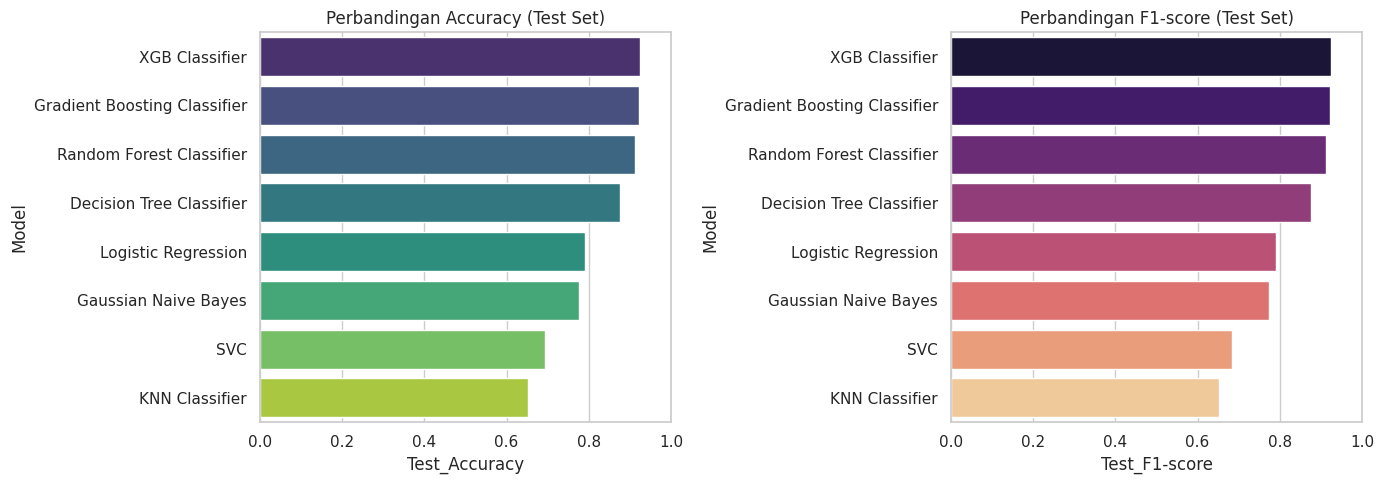

In [ ]:
# Visualisasi perbandingan Accuracy & F1-score antar model (test set)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=classification_results_df, x="Test_Accuracy", y="Model", ax=axes[0], palette="viridis")
axes[0].set_title("Perbandingan Accuracy (Test Set)")
axes[0].set_xlim(0, 1)

sns.barplot(data=classification_results_df, x="Test_F1-score", y="Model", ax=axes[1], palette="magma")
axes[1].set_title("Perbandingan F1-score (Test Set)")
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()


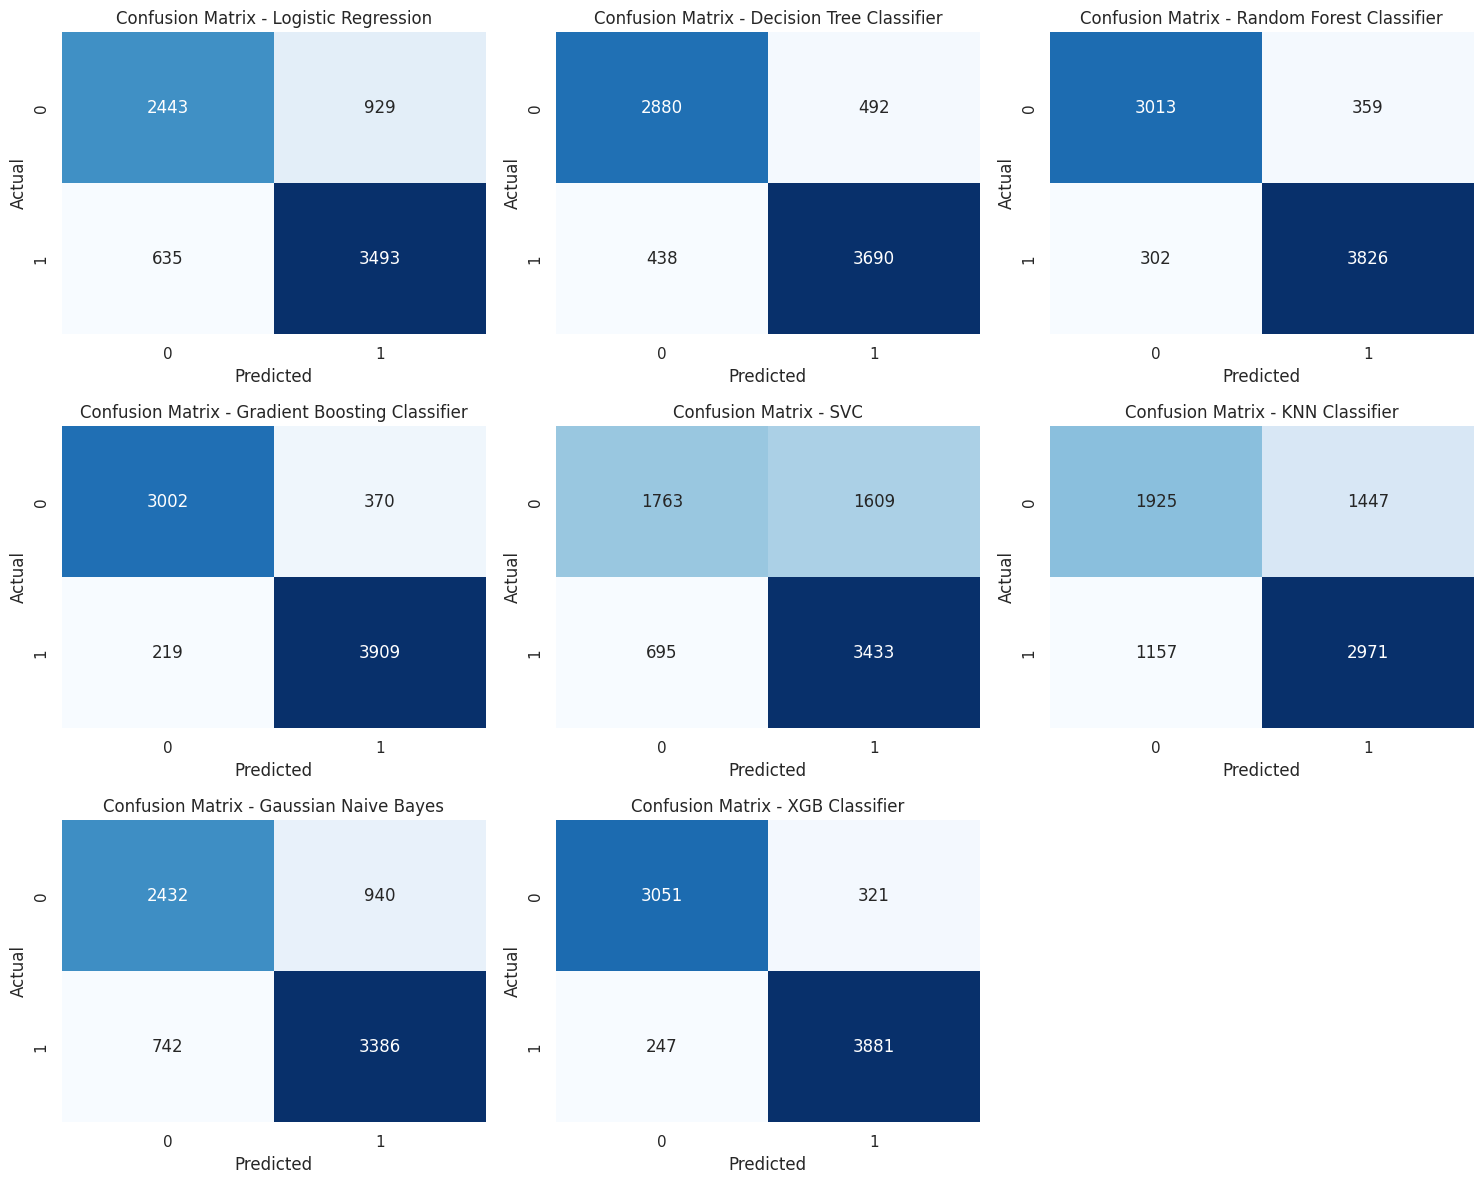

In [ ]:
# Confusion Matrix untuk setiap model klasifikasi (test set)
n_models = len(fitted_classification_models)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(-1)

class_labels = sorted(pd.Series(y_test_clf).unique())

for idx, (name, model) in enumerate(fitted_classification_models.items()):
    y_test_pred = model.predict(X_test_clf)
    cm = confusion_matrix(y_test_clf, y_test_pred, labels=class_labels)

    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_labels, yticklabels=class_labels,
        ax=axes[idx], cbar=False
    )
    axes[idx].set_title(f"Confusion Matrix - {name}")
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

# Sembunyikan subplot kosong jika ada
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


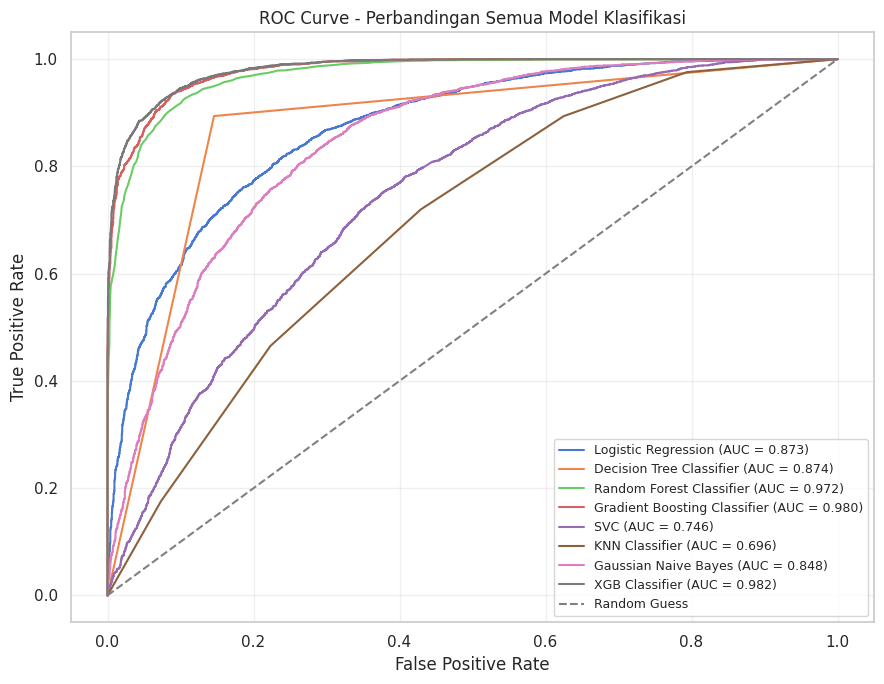

In [ ]:
n_classes = len(class_labels)
is_binary = n_classes == 2

plt.figure(figsize=(9, 7))

for name, model in fitted_classification_models.items():
    if not hasattr(model, "predict_proba"):
        print(f"{name} tidak memiliki predict_proba, dilewati untuk ROC-AUC.")
        continue

    y_score = model.predict_proba(X_test_clf)

    if is_binary:
        # Ambil probabilitas kelas positif (kelas dengan label lebih besar/kedua)
        pos_label = class_labels[1]
        y_test_binary = (pd.Series(y_test_clf) == pos_label).astype(int)
        fpr, tpr, _ = roc_curve(y_test_binary, y_score[:, 1])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")
    else:
        # Multiclass -> One-vs-Rest, macro-average
        y_test_bin = label_binarize(y_test_clf, classes=class_labels)
        fpr_dict, tpr_dict = {}, {}

        for i in range(n_classes):
            fpr_dict[i], tpr_dict[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])

        # Macro-average ROC
        all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(n_classes)]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(n_classes):
            mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
        mean_tpr /= n_classes

        roc_auc_macro = auc(all_fpr, mean_tpr)
        plt.plot(all_fpr, mean_tpr, label=f"{name} (macro AUC = {roc_auc_macro:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Perbandingan Semua Model Klasifikasi")
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Feature Engineering: Create new features from existing ones

# Make a copy of X_clf to add new features for feature engineering scenario
X_clf_fe = X_clf.copy()

# 1. Interaction feature: lama_bekerja_tahun * total_indikator_risiko
X_clf_fe['lama_bekerja_risiko_interaksi'] = X_clf_fe['lama_bekerja_tahun'] * X_clf_fe['total_indikator_risiko']

# 2. Ratio feature: total_aset_neto per jumlah_pinjaman (handle division by zero)
# Add a small epsilon to avoid division by zero if jumlah_pinjaman can be 0 or very small
X_clf_fe['rasio_aset_pinjaman_neto'] = X_clf_fe['total_aset_neto'] / (X_clf_fe['jumlah_pinjaman'] + 1e-6)

# 3. Interaction feature: usia * total_indikator_risiko
X_clf_fe['usia_risiko_interaksi'] = X_clf_fe['usia'] * X_clf_fe['total_indikator_risiko']

# 4. Interaction feature: usia * skor_kredit
X_clf_fe['usia_skorkredit_interaksi'] = X_clf_fe['usia'] * X_clf_fe['skor_kredit']

print("New features created in X_clf_fe:")
print(X_clf_fe.head())
print(f"New shape of X_clf_fe: {X_clf_fe.shape}")

# Now, you would typically re-split the data using X_clf_fe and y_clf,
# and then re-train and re-evaluate your models to see the impact of these new features.
# For example:
# X_train_clf_fe, X_val_clf_fe, X_test_clf_fe, y_train_clf, y_val_clf, y_test_clf = split_train_val_test(
#     X_clf_fe, y_clf,
#     test_size=0.15,
#     val_size=0.15,
#     stratify=True
# )
# Then rerun the model training and evaluation process with these new splits.

New features created in X_clf_fe:
     usia  lama_bekerja_tahun  pendapatan_tahunan  skor_kredit  \
0 40.0000             17.2000          25579.0000          692   
1 33.0000              7.3000          43087.0000          627   
2 42.0000              1.1000          20840.0000          689   
3 53.0000              0.5000          29147.0000          692   
4 32.0000             12.5000          63657.0000          630   

   lama_riwayat_kredit_tahun  aset_tabungan  hutang_saat_ini  \
0                     5.3000       895.0000       10820.0000   
1                     3.5000       169.0000       16550.0000   
2                     8.4000        17.0000        7852.0000   
3                     9.8000      1480.0000       11603.0000   
4                     7.2000       209.0000       12424.0000   

   gagal_bayar_tercatat  tunggakan_2thn_terakhir  catatan_negatif  \
0                     0                        0                0   
1                     0                       

In [ ]:
# Drop the original features that were used to create the new engineered features
# to avoid data leakage and redundancy.
# The features to drop are 'usia' and 'lama_bekerja_tahun', as new interaction features
# involving them have been created. Other original features or intermediate engineered features
# like 'skor_kredit', 'jumlah_pinjaman', 'total_aset_neto', and 'total_indikator_risiko'
# are kept as they likely retain independent predictive power or represent important aggregations.
features_to_drop = ['usia', 'lama_bekerja_tahun', 'total_indikator_risiko', 'total_aset_neto', 'jumlah_pinjaman', 'skor_kredit']

X_clf_fe_dropped = X_clf_fe.drop(columns=features_to_drop)

print("Original X_clf_fe head:")
print(X_clf_fe.head())
print(f"Original X_clf_fe shape: {X_clf_fe.shape}")

print("\nFeatures dropped:", features_to_drop)
print("\nNew X_clf_fe_dropped head:")
print(X_clf_fe_dropped.head())
print(f"New X_clf_fe_dropped shape: {X_clf_fe_dropped.shape}")

# Now, you should use X_clf_fe_dropped for further model training and evaluation.

Original X_clf_fe head:
     usia  lama_bekerja_tahun  pendapatan_tahunan  skor_kredit  \
0 40.0000             17.2000          25579.0000          692   
1 33.0000              7.3000          43087.0000          627   
2 42.0000              1.1000          20840.0000          689   
3 53.0000              0.5000          29147.0000          692   
4 32.0000             12.5000          63657.0000          630   

   lama_riwayat_kredit_tahun  aset_tabungan  hutang_saat_ini  \
0                     5.3000       895.0000       10820.0000   
1                     3.5000       169.0000       16550.0000   
2                     8.4000        17.0000        7852.0000   
3                     9.8000      1480.0000       11603.0000   
4                     7.2000       209.0000       12424.0000   

   gagal_bayar_tercatat  tunggakan_2thn_terakhir  catatan_negatif  \
0                     0                        0                0   
1                     0                        1        

Correlations with 'status_pinjaman' (Feature Engineered Data):
status_pinjaman                         1.0000
usia_skorkredit_interaksi               0.3969
lama_riwayat_kredit_tahun               0.2771
aset_tabungan                           0.1908
kategori_usia_Dewasa                    0.1796
pendapatan_tahunan                      0.1626
kategori_usia_Senior                    0.1440
tujuan_pinjaman_Pendidikan              0.1263
rasio_aset_terhadap_pinjaman            0.1088
tujuan_pinjaman_Pribadi                 0.0668
rasio_aset_pinjaman_neto                0.0212
status_pekerjaan_Wiraswasta             0.0188
status_pekerjaan_Mahasiswa              0.0072
tujuan_pinjaman_Renovasi Rumah         -0.0128
tipe_produk_Kredit Berjalan            -0.0181
tujuan_pinjaman_Medis                  -0.0183
hutang_saat_ini                        -0.0831
tipe_produk_Pinjaman Pribadi           -0.1035
tujuan_pinjaman_Konsolidasi Hutang     -0.1221
lama_bekerja_risiko_interaksi          -0.16

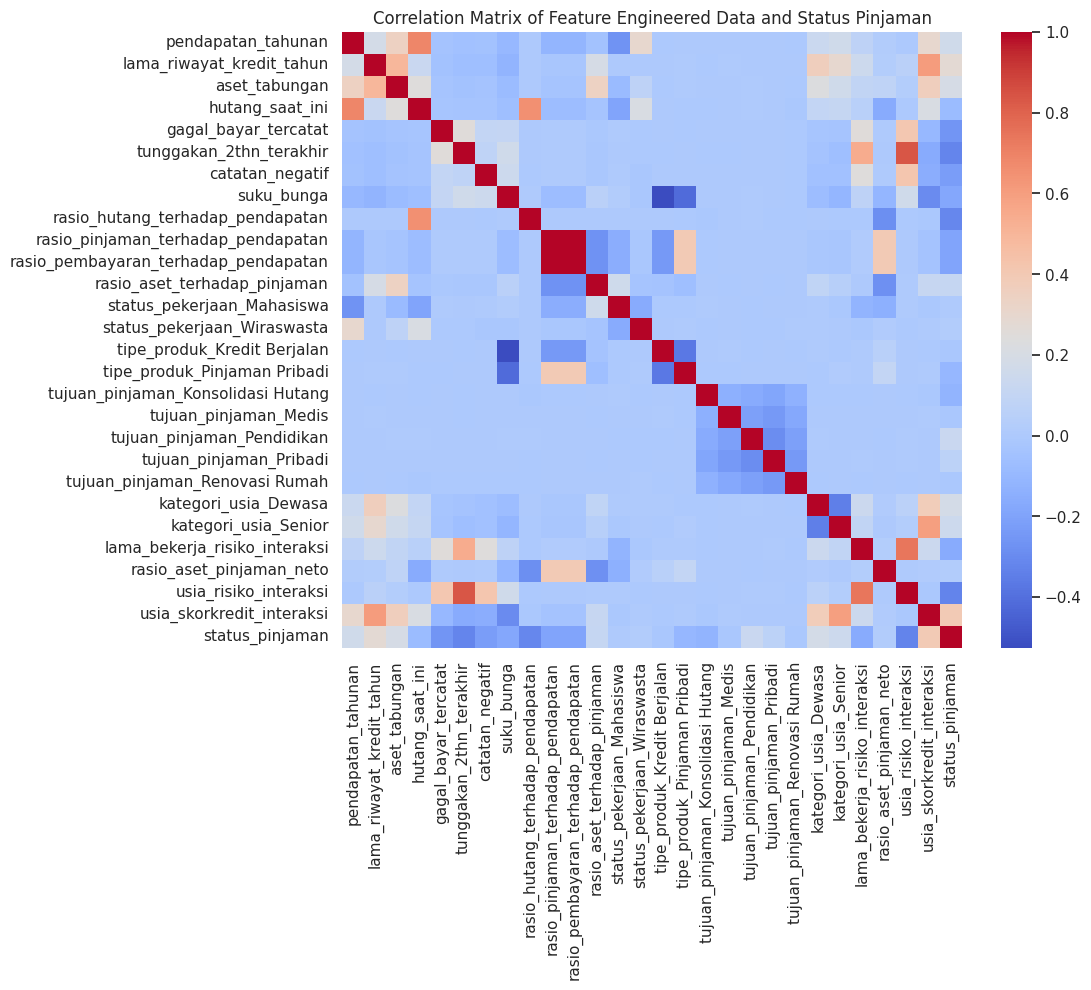

In [ ]:
# Combine X_clf_fe_dropped and y_clf for correlation calculation
df_fe_corr = pd.concat([X_clf_fe_dropped, y_clf], axis=1)

# Calculate the correlation matrix
correlation_matrix = df_fe_corr.corr()

# Get correlations with the target variable 'status_pinjaman'
churn_correlations = correlation_matrix['status_pinjaman'].sort_values(ascending=False)

print("Correlations with 'status_pinjaman' (Feature Engineered Data):")
print(churn_correlations)

# Visualize the correlations with a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Feature Engineered Data and Status Pinjaman')
plt.show()

In [ ]:
# Re-split the data using the feature-engineered and dropped dataset
X_train_clf_fe, X_val_clf_fe, X_test_clf_fe, y_train_clf_fe, y_val_clf_fe, y_test_clf_fe = split_train_val_test(
    X_clf_fe_dropped, y_clf,
    test_size=0.15,
    val_size=0.15,
    stratify=True
)

# Get the XGB Classifier model from the already fitted models
XGB_model = fitted_classification_models["XGB Classifier"]

# Fit the XGB model on the new feature-engineered training data
print("\nFitting XGB Classifier with feature-engineered data...")
knn_model.fit(X_train_clf_fe, y_train_clf_fe)
print("XGB Classifier has been fitted successfully with feature-engineered data.")

# You can now evaluate this `XGB_model` on X_val_clf_fe and X_test_clf_fe

Jumlah data Train : 34999 (70.0%)
Jumlah data Val   : 7501 (15.0%)
Jumlah data Test  : 7500 (15.0%)

Fitting XGB Classifier with feature-engineered data...
XGB Classifier has been fitted successfully with feature-engineered data.


In [ ]:
from sklearn.metrics import classification_report

y_pred_best_model = best_model.predict(X_test_clf)
report = classification_report(y_test_clf, y_pred_best_model, target_names=[str(c) for c in class_labels])

print("Classification Report for Best Model (XGB Classifier):")
print(report)

Classification Report for Best Model (XGB Classifier):
              precision    recall  f1-score   support

           0       0.93      0.90      0.91      3372
           1       0.92      0.94      0.93      4128

    accuracy                           0.92      7500
   macro avg       0.92      0.92      0.92      7500
weighted avg       0.92      0.92      0.92      7500



In [ ]:
xgb_tuning_result = classification_results_df[classification_results_df['Model'] == 'XGB Classifier']
print(xgb_tuning_result.to_markdown(index=False))

| Model          |   Val_Accuracy |   Val_Precision |   Val_Recall |   Val_F1-score |   Test_Accuracy |   Test_Precision |   Test_Recall |   Test_F1-score |
|:---------------|---------------:|----------------:|-------------:|---------------:|----------------:|-----------------:|--------------:|----------------:|
| XGB Classifier |       0.927343 |         0.92732 |     0.927343 |       0.927291 |        0.924267 |         0.924281 |      0.924267 |        0.924183 |


In [ ]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Helper function to evaluate classification metrics
def evaluate_classification(y_true, y_pred, average="weighted"):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average=average, zero_division=0)
    rec = recall_score(y_true, y_pred, average=average, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=average, zero_division=0)
    return {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1}

# 1. KNN (Default params, Original features)
default_knn_original = KNeighborsClassifier()
default_knn_original.fit(X_train_clf, y_train_clf)
y_pred_default_knn_original = default_knn_original.predict(X_test_clf)
default_original_metrics = evaluate_classification(y_test_clf, y_pred_default_knn_original)

# 2. KNN (Tuned params, Original features) - from classification_results_df
tuned_knn_original_metrics_row = classification_results_df[classification_results_df['Model'] == 'XGB Classifier']
tuned_original_metrics = {
    'Accuracy': tuned_knn_original_metrics_row['Test_Accuracy'].values[0],
    'Precision': tuned_knn_original_metrics_row['Test_Precision'].values[0],
    'Recall': tuned_knn_original_metrics_row['Test_Recall'].values[0],
    'F1-score': tuned_knn_original_metrics_row['Test_F1-score'].values[0]
}

# 3. KNN (Tuned params, Feature-engineered features) - re-calculating from the last fitted model
y_pred_knn_fe = knn_model.predict(X_test_clf_fe)
tuned_fe_metrics = evaluate_classification(y_test_clf_fe, y_pred_knn_fe)

# Create a DataFrame for comparison
comparison_data = [
    {"Model Scenario": "XGB (Default, Original Features)", **default_original_metrics},
    {"Model Scenario": "XGB (Tuned, Original Features)", **tuned_original_metrics},
    {"Model Scenario": "XGB (Tuned, Feature-Engineered Features)", **tuned_fe_metrics}
]
comparison_df = pd.DataFrame(comparison_data)

print("Perbandingan Performa Model XGB:")
display(comparison_df)

Perbandingan Performa Model XGB:


,Model Scenario,Accuracy,Precision,Recall,F1-score
0,"XGB (Default, Original Features)",0.6528,0.6509,0.6528,0.6509
1,"XGB (Tuned, Original Features)",0.9243,0.9243,0.9243,0.9242
2,"XGB (Tuned, Feature-Engineered Features)",0.7255,0.7246,0.7255,0.7242


Model Terbaik (berdasarkan F1-score Test Set): XGB Classifier


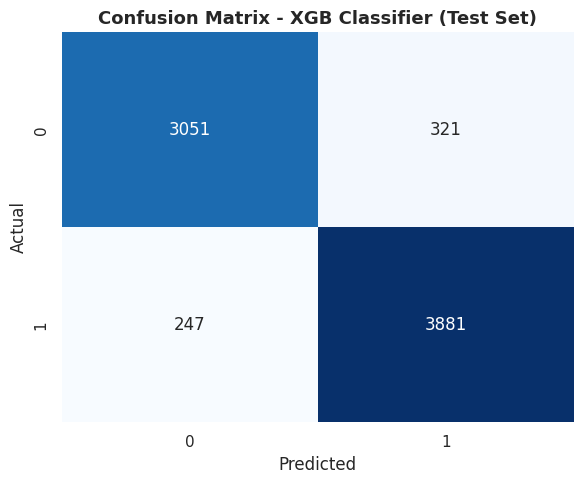

In [ ]:
best_model_name = classification_results_df.iloc[0]['Model']
best_model = fitted_classification_models[best_model_name]

print(f"Model Terbaik (berdasarkan F1-score Test Set): {best_model_name}")

y_pred_best_model = best_model.predict(X_test_clf)

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test_clf, y_pred_best_model, labels=class_labels)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=class_labels, yticklabels=class_labels,
    cbar=False
)
plt.title(f"Confusion Matrix - {best_model_name} (Test Set)", fontsize=13, fontweight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()